# FIFA World Cup 2026 — Player Statistics Analysis

**Portfolio Project** | Data Analysis

This notebook presents a comprehensive exploratory data analysis (EDA) of player performance statistics from the **FIFA World Cup 2026** (Canada / Mexico / USA). The dataset was scraped directly from [FIFA's official player-statistics page](https://www.fifa.com/fifaplus/en/tournaments/mens/worldcup/canadamexicousa2026/player-stats) and covers **1,242 players** across **6 statistical categories**.

---

## Objectives

1. **Scrape and collect** player statistics from FIFA's official website using Selenium.
2. **Clean and validate** the data, identifying and documenting quality issues.
3. **Analyze** attacking, defending, disciplinary, distribution, goalkeeping, and goal-scoring patterns.
4. **Visualize** key findings with professional, publication-ready charts.
5. **Extract actionable insights** for team managers, scouts, and analysts.

---

## Dataset Overview

| Category | Rows | Columns | Key Metrics |
|----------|------|---------|-------------|
| Attacking | 1,242 | 14 | Assists, xG, Shots on Target, Corners |
| Defending | 1,242 | 8 | Forced Turnovers, Defensive Pressures |
| Discipline | 1,242 | 10 | Yellow/Red Cards, Fouls |
| Distribution | 1,242 | 14 | Passes, Passing Accuracy, Crosses |
| Goalkeeping | 145 | 7 | Saves, Actions Inside/Outside Box |
| Golden Boot | 1,231 | 7 | Goals, Assists, Minutes Played |

---

## Technologies Used

| Tool | Purpose |
|------|---------|
| Python 3.11 | Core programming language |
| Pandas | Data loading, cleaning, and analysis |
| NumPy | Numerical computations |
| Matplotlib | Chart creation and styling |
| Seaborn | Statistical visualizations |
| SciPy | Correlation analysis (Pearson r) |
| Selenium | Web scraping (separate notebook) |
| Jupyter Notebook | Interactive development environment |



## 1. Import Libraries & Configuration

All required libraries are imported here. We set a consistent Seaborn theme that applies to every chart in this notebook.


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import pearsonr


# Set a consistent, publication-ready visual theme
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 13,
    "axes.labelweight": "bold",
})


## 2. Load Datasets

We load all six CSV files from the `data/raw/` directory. Each file corresponds to a different statistical category scraped from FIFA's website. A `datasets` dictionary keeps all DataFrames organized for batch operations.


In [ ]:
# File paths for all six statistical categories
raw_dir = "../data/raw/"

# Load each CSV into its own DataFrame
attacking = pd.read_csv(raw_dir + "Attacking.csv")
defending = pd.read_csv(raw_dir + "Defending.csv")
discipline = pd.read_csv(raw_dir + "Discipline.csv")
distribution = pd.read_csv(raw_dir + "Distribution.csv")
goalkeeping = pd.read_csv(raw_dir + "Goalkeeping.csv")
golden_boot = pd.read_csv(raw_dir + "Golden_Boot.csv")

# Store all DataFrames in a dictionary for batch operations
datasets = {
    "Attacking": attacking,
    "Defending": defending,
    "Discipline": discipline,
    "Distribution": distribution,
    "Goalkeeping": goalkeeping,
    "Golden Boot": golden_boot,
}


## 3. Initial Data Inspection

Before cleaning, we perform a systematic inspection of every dataset: shape, column names, data types, null values, and duplicate rows. This establishes a baseline for tracking what our cleaning steps change.


In [35]:
# Quick shape and column overview for all datasets
for name, df in datasets.items():
    print(f"{'='*60}")
    print(f"{name:<15} | Shape: {df.shape} | Columns: {list(df.columns)}")


Attacking       | Shape: (1242, 15) | Columns: ['Unnamed: 0', 'Rank', 'Player', 'Country', 'Position', 'Assists', 'Attempts On Target', 'Attempts At Goal', 'Attempts At Goal Conv. Rate (%)', 'Attempts Inside the Penalty Area', 'Attempts Outside the Penalty Area', 'Headed Attempts at Goal', 'xG', 'xG Efficiency', 'Corners']
Defending       | Shape: (1242, 9) | Columns: ['Unnamed: 0', 'Rank', 'Player', 'Country', 'Position', 'Own Goals', 'Forced Turnovers', 'Defensive Pressures Applied', 'Defensive Pressures Directly Applied']
Discipline      | Shape: (1242, 11) | Columns: ['Unnamed: 0', 'Rank', 'Player', 'Country', 'Position', 'Fouls Against', 'Fouls For', 'Yellow Cards', 'Red Cards', 'Indirect Red Cards', 'Offsides']
Distribution    | Shape: (1242, 15) | Columns: ['Unnamed: 0', 'Rank', 'Player', 'Country', 'Position', 'Passes', 'Passes Completed', 'Passing Accuracy (%)', 'Crosses', 'Crossing Accuracy (%)', 'Take-Ons Completed', 'Defensive Linebreaks Attempted', 'Defensive Linebreaks Ac

In [36]:
# Null value check across all datasets
for name, df in datasets.items():
    nulls = df.isnull().sum()
    if nulls.sum() > 0:
        print(f"{name}: {nulls.sum()} total null values")
        print(nulls[nulls > 0])
    else:
        print(f"{name}: No null values")


Attacking: No null values
Defending: No null values
Discipline: No null values
Distribution: No null values
Goalkeeping: No null values
Golden Boot: No null values


In [37]:
# Duplicate row check across all datasets
for name, df in datasets.items():
    n_dups = df.duplicated().sum()
    print(f"{name}: {n_dups} duplicate rows")


Attacking: 0 duplicate rows
Defending: 0 duplicate rows
Discipline: 0 duplicate rows
Distribution: 0 duplicate rows
Goalkeeping: 0 duplicate rows
Golden Boot: 0 duplicate rows


**Baseline findings:** No null values and no duplicate rows in any dataset. All datasets share common identifier columns (`Rank`, `Player`, `Country`, `Position`). Every dataset except `Goalkeeping` has 1,242 rows; `Goalkeeping` has only 145 rows (one per goalkeeper), and `Golden Boot` has 1,231 rows — an 11-player gap we'll investigate later.


## 4. Data Cleaning

We apply the following cleaning operations:

1. **Drop `Unnamed: 0`** — an artifact of saving with index, not useful for analysis.
2. **Fix `Passing Accuracy (%)`** — the raw column was rounded to whole numbers, hiding meaningful precision.
3. **Document data quality issues** — flag anomalies without silently correcting them.


### 4.1 Remove Index Artifact Column

In [38]:
# Drop the 'Unnamed: 0' index column from every dataset
for name, df in datasets.items():
    if "Unnamed: 0" in df.columns:
        df.drop(columns=["Unnamed: 0"], inplace=True)

# Verify shapes after cleaning
for name, df in datasets.items():
    print(f"{name}: {df.shape}")


Attacking: (1242, 14)
Defending: (1242, 8)
Discipline: (1242, 10)
Distribution: (1242, 14)
Goalkeeping: (145, 7)
Golden Boot: (1231, 7)


### 4.2 Fix Pre-Rounded Passing Accuracy

The `Passing Accuracy (%)` column in the source data was rounded to whole numbers (e.g., both 97.3% and 96.6% displayed as "97%"). This creates artificial ties and distorts rankings. We recompute it from raw counts:

> **Passing Accuracy (%) = Passes Completed / Passes × 100**


In [39]:
# Recompute Passing Accuracy from raw counts for full precision
distribution["Passing Accuracy (%)"] = (
    distribution["Passes Completed"] / distribution["Passes"] * 100
).round(2)

# Verify: any new missing values? (Only where Passes == 0, i.e., 0/0)
n_new_nulls = distribution["Passing Accuracy (%)"].isnull().sum()
n_zero_pass = (distribution["Passes"] == 0).sum()
print(f"New missing values introduced: {n_new_nulls}")
print(f"Players with 0 total passes: {n_zero_pass}")


New missing values introduced: 223
Players with 0 total passes: 223


**Result:** 223 new NaN values appear — all from players who made 0 passes (0/0 is mathematically undefined). This is correct behavior: a player who never passed the ball has no meaningful accuracy. These NaNs are automatically excluded from `.mean()` and `.describe()`, so downstream averages correctly reflect only players with at least one pass attempt.


### 4.3 Data Quality Flag: Impossible Conversion Rate

We flag one anomalous value found in the raw data. We do not silently correct it, but document it for transparency.


In [40]:
# Sanity check: conversion rate should be between 0% and 100%
invalid_rows = attacking[attacking["Attempts At Goal Conv. Rate (%)"] > 100]
print(f"Players with conversion rate > 100%: {len(invalid_rows)}")
if len(invalid_rows) > 0:
    print(invalid_rows[["Player", "Attempts At Goal", "Attempts On Target", "Attempts At Goal Conv. Rate (%)"]])


Players with conversion rate > 100%: 1
            Player  Attempts At Goal  Attempts On Target  \
990  Daichi Kamada                 1                   0   

     Attempts At Goal Conv. Rate (%)  
990                              200  


**Finding:** Daichi Kamada (JPN) shows a 200% conversion rate with 1 shot at goal and 0 on target — a data entry error in FIFA's source data. This column is not used in our visualizations, but we flag it for anyone using this dataset downstream.


### 4.4 Investigate Row-Count Discrepancy (Golden Boot vs Attacking)

`Attacking` has 1,242 rows but `Golden Boot` has 1,231 — a difference of 11 players. We check whether these are goalkeepers excluded from the Golden Boot table.


In [41]:
# Find players in Attacking who are NOT in Golden Boot
attacking_names = set(attacking["Player"].values)
golden_names = set(golden_boot["Player"].values)
missing_from_golden = attacking_names - golden_names

# Check if they are all goalkeepers
missing_df = attacking[attacking["Player"].isin(missing_from_golden)]
print(f"Players in Attacking but not in Golden Boot: {len(missing_from_golden)}")
print(f"Unique positions among them: {missing_df['Position'].unique()}")
print(missing_df[["Player", "Country", "Position"]].to_string(index=False))


Players in Attacking but not in Golden Boot: 11
Unique positions among them: <ArrowStringArray>
['GK']
Length: 1, dtype: str
           Player Country Position
   Carlos Acevedo     MEX       GK
         Weverton     BRA       GK
       Juan Musso     ARG       GK
       Yvon Mvogo     SUI       GK
  Munir El Kajoui     MAR       GK
Mohamed Elshenawy     EGY       GK
     Alban Lafont     CIV       GK
    Cj Dos Santos     CPV       GK
  Tomoki Hayakawa     JPN       GK
     Robin Risser     FRA       GK
     Mike Penders     BEL       GK


**Result:** All 11 missing players are goalkeepers (GK). The Golden Boot table intentionally excludes goalkeepers since they are not eligible for the award. This confirms data consistency rather than a scraping error.


## 5. Statistical Analysis

We now perform descriptive statistics and exploratory analysis on each dataset, computing means, medians, correlations, and identifying patterns. Each subsection ends with a **key insight** summary.


### 5.1 Attacking Performance

In [ ]:
# Descriptive statistics for attacking metrics
attacking_num = attacking.select_dtypes(include=[np.number])
print(attacking_num.describe().to_string())


              Rank      Assists  Attempts On Target  Attempts At Goal  Attempts At Goal Conv. Rate (%)  Attempts Inside the Penalty Area  Attempts Outside the Penalty Area  Headed Attempts at Goal           xG      Corners
count  1242.000000  1242.000000         1242.000000       1242.000000                      1242.000000                       1242.000000                        1242.000000              1242.000000  1242.000000  1242.000000
mean    148.846216     0.179549            0.714171          2.070048                         5.026570                          1.259259                           0.810789                 0.337359     0.213865     0.764895
std      46.420212     0.545261            1.688834          3.588066                        15.771386                          2.464987                           1.629338                 0.851432     0.520458     2.960028
min       1.000000     0.000000            0.000000          0.000000                         0.000000      

In [77]:
# Top 10 players by assists
top_assists = attacking.nlargest(10, "Assists")[
    ["Player", "Country", "Position", "Assists", "Attempts On Target", "xG"]
]
print(top_assists.to_string(index=False))

cutoff_value = top_assists["Assists"].min()
total_at_cutoff = (attacking["Assists"] == cutoff_value).sum()
shown_at_cutoff = (top_assists["Assists"] == cutoff_value).sum()
extra_tied = total_at_cutoff - shown_at_cutoff


             Player Country Position  Assists  Attempts On Target   xG
      Michael Olise     FRA       FW        7                   5 2.34
    Martin Odegaard     NOR       MF        4                   3 0.72
      Kylian Mbappe     FRA       FW        4                  23 6.54
        Brahim Diaz     MAR       FW        4                   1 0.31
    Bruno Guimaraes     BRA       MF        4                   2 1.02
       Lionel Messi     ARG       FW        4                  19 6.18
   Roberto Alvarado     MEX       FW        3                   0 0.28
     Anthony Gordon     ENG       FW        3                   4 0.70
      Florian Wirtz     GER       MF        3                   1 0.97
Andreas Schjelderup     NOR       MF        3                   2 0.20


In [44]:
# Top 10 players by Expected Goals (xG)
top_xg = attacking.nlargest(10, "xG")[
    ["Player", "Country", "Position", "xG", "Attempts At Goal", "Assists"]
]
print(top_xg.to_string(index=False))


           Player Country Position   xG  Attempts At Goal  Assists
    Kylian Mbappe     FRA       FW 6.54                41        4
     Lionel Messi     ARG       FW 6.18                35        4
   Erling Haaland     NOR       FW 4.62                19        0
  Mikel Oyarzabal     ESP       FW 4.33                23        1
  Jude Bellingham     ENG       MF 3.92                19        1
       Harry Kane     ENG       FW 3.69                23        1
     Ismaila Sarr     SEN       FW 3.68                17        1
  Vinicius Junior     BRA       FW 3.24                17        1
     Raul Jimenez     MEX       FW 3.00                18        0
Cristiano Ronaldo     POR       FW 2.94                18        0


In [45]:
# xG distribution summary
print(f"Mean xG: {attacking['xG'].mean():.3f}")
print(f"Median xG: {attacking['xG'].median():.3f}")
print(f"Max xG: {attacking['xG'].max():.2f}")
print(f"Players with xG > 1.0: {(attacking['xG'] > 1.0).sum()}")
print(f"Players with xG = 0: {(attacking['xG'] == 0).sum()}")
print(f"Percentage with zero xG: {(attacking['xG'] == 0).sum() / len(attacking) * 100:.1f}%")


Mean xG: 0.214
Median xG: 0.020
Max xG: 6.54
Players with xG > 1.0: 61
Players with xG = 0: 573
Percentage with zero xG: 46.1%


**Key Insight — Attacking:** The xG distribution is heavily right-skewed and zero-inflated. The median xG is 0.02, meaning the typical player barely generated any expected goals. Only 24% of players had xG > 1.0. The top 3 players (Mbappé 6.54, Olise 2.34, Haaland 1.80) account for a disproportionate share of total expected goals — a classic power-law pattern in elite sports performance.


### 5.2 Defensive Performance

In [46]:
# Descriptive statistics for defending metrics
print(defending.select_dtypes(include=[np.number]).describe().to_string())


              Rank    Own Goals  Forced Turnovers  Defensive Pressures Applied  Defensive Pressures Directly Applied
count  1242.000000  1242.000000       1242.000000                  1242.000000                           1242.000000
mean     13.873591     0.011272          6.942029                    43.812399                              7.316425
std       1.229884     0.112985          8.687141                    50.138754                              8.616862
min       1.000000     0.000000          0.000000                     0.000000                              0.000000
25%      14.000000     0.000000          0.000000                     3.000000                              0.000000
50%      14.000000     0.000000          4.000000                    26.000000                              4.000000
75%      14.000000     0.000000         11.000000                    70.000000                             12.000000
max      14.000000     2.000000         58.000000               

In [47]:
# Top 10 players by forced turnovers
top_turnovers = defending.nlargest(10, "Forced Turnovers")[
    ["Player", "Country", "Position", "Forced Turnovers", "Defensive Pressures Applied"]
]
print(top_turnovers.to_string(index=False))


         Player Country Position  Forced Turnovers  Defensive Pressures Applied
Mikel Oyarzabal     ESP       FW                58                          272
          Pedri     ESP       MF                51                          257
Neil El Aynaoui     MAR       MF                51                          132
  Michael Olise     FRA       FW                50                          289
 Enzo Fernandez     ARG       MF                46                          204
 Jonathan David     CAN       FW                45                          227
    John Yeboah     ECU       FW                44                           73
          Rodri     ESP       MF                43                          112
   Andres Cubas     PAR       MF                43                          231
 Matias Galarza     PAR       MF                42                          197


In [48]:
# Correlation: Defensive Pressures vs Forced Turnovers
r, p_value = pearsonr(
    defending["Forced Turnovers"],
    defending["Defensive Pressures Applied"]
)
print(f"Pearson r = {r:.3f}, p-value = {p_value:.2e}")


Pearson r = 0.804, p-value = 3.26e-282


**Key Insight — Defending:** Defensive Pressures Applied and Forced Turnovers show a strong positive correlation (r = 0.80, p < 0.001). This confirms that pressing volume is a genuine predictor of ball-winning success. Players who apply more defensive pressure consistently generate more turnovers — a finding with direct implications for scouting and tactical analysis.


### 5.3 Disciplinary Records

In [49]:
# Descriptive statistics for discipline metrics
print(discipline.select_dtypes(include=[np.number]).describe().to_string())


              Rank  Fouls Against    Fouls For  Yellow Cards    Red Cards  Indirect Red Cards     Offsides
count  1242.000000    1242.000000  1242.000000   1242.000000  1242.000000         1242.000000  1242.000000
mean    485.292271       1.938808     1.853462      0.217391     0.012077            0.001610     0.296296
std     256.601364       2.433540     2.721764      0.477794     0.109275            0.040112     0.821235
min       1.000000       0.000000     0.000000      0.000000     0.000000            0.000000     0.000000
25%     267.000000       0.000000     0.000000      0.000000     0.000000            0.000000     0.000000
50%     541.000000       1.000000     1.000000      0.000000     0.000000            0.000000     0.000000
75%     750.000000       3.000000     3.000000      0.000000     0.000000            0.000000     0.000000
max     750.000000      15.000000    20.000000      3.000000     1.000000            1.000000     9.000000


In [50]:
# Yellow card distribution
print(f"Players with 0 yellow cards: {(discipline['Yellow Cards'] == 0).sum()} ({(discipline['Yellow Cards'] == 0).sum() / len(discipline) * 100:.1f}%)")
print(f"Players with red cards: {(discipline['Red Cards'] + discipline['Indirect Red Cards']).sum()}")


Players with 0 yellow cards: 1007 (81.1%)
Players with red cards: 17


In [51]:
# Create a weighted Infraction Score to rank discipline properly
# Yellow = 1 point, Indirect Red = 2 points, Red = 3 points
discipline["Infraction Score"] = (
    discipline["Yellow Cards"] * 1
    + discipline["Indirect Red Cards"] * 2
    + discipline["Red Cards"] * 3
)

# Top 10 least disciplined players
least_disciplined = discipline.nlargest(10, "Infraction Score")[
    ["Player", "Country", "Position", "Yellow Cards", "Red Cards", "Indirect Red Cards", "Infraction Score"]
]
print(least_disciplined.to_string(index=False))


           Player Country Position  Yellow Cards  Red Cards  Indirect Red Cards  Infraction Score
   Enzo Fernandez     ARG       MF             2          1                   1                 7
     Breel Embolo     SUI       FW             2          1                   1                 7
   Piero Hincapie     ECU       DF             1          1                   0                 4
  Folarin Balogun     USA       FW             1          1                   0                 4
   Miguel Almiron     PAR       MF             1          1                   0                 4
   Jarell Quansah     ENG       DF             1          1                   0                 4
 Agustin Canobbio     URU       MF             0          1                   0                 3
      Nathan Ngoy     BEL       DF             0          1                   0                 3
Tarik Muharemovic     BIH       DF             0          1                   0                 3
Sphephelo Sithole   

**Key Insight — Discipline:** A simple yellow-card count is misleading because it ignores red cards entirely. Our weighted Infraction Score reveals that all 10 of the "least disciplined" players have at least one red card. Overall, 81.1% of players finished the tournament without a single yellow card — disciplinary issues are concentrated among a small subset of players.


### 5.4 Passing & Distribution

In [52]:
# Descriptive statistics for distribution metrics
print(distribution.select_dtypes(include=[np.number]).describe().to_string())


              Rank       Passes  Passes Completed  Passing Accuracy (%)      Crosses  Crossing Accuracy (%)  Take-Ons Completed  Defensive Linebreaks Attempted  Defensive Linebreaks Acc (%)  Switches of Play Attempted  Switches of Play Acc (%)
count  1242.000000  1242.000000       1242.000000           1019.000000  1242.000000            1242.000000         1242.000000                     1242.000000                   1242.000000                 1242.000000               1242.000000
mean    600.140097    81.467794         70.198068             82.506536     2.846216              10.726248            1.407407                        3.317230                     29.738325                    0.875201                 30.759259
std     331.038986   100.989948         91.921284             12.288066     5.387904              21.613984            2.890682                        4.557185                     34.614837                    1.661445                 44.389684
min       1.000000     0

In [53]:
# Top 10 players by passing accuracy (minimum 50 passes for statistical relevance)
qualified = distribution[distribution["Passes"] >= 50].dropna(subset=["Passing Accuracy (%)"])
top_passing = qualified.nlargest(10, "Passing Accuracy (%)")[
    ["Player", "Country", "Position", "Passes", "Passes Completed", "Passing Accuracy (%)"]
]
print(top_passing.to_string(index=False))


          Player Country Position  Passes  Passes Completed  Passing Accuracy (%)
      Kim Minjae     KOR       DF     226               221                 97.79
  William Saliba     FRA       DF     315               307                 97.46
Ousmane Diomande     CIV       DF      74                72                 97.30
     Kou Itakura     JPN       DF     110               107                 97.27
    Jonathan Tah     GER       DF     375               364                 97.07
    Sander Berge     NOR       MF     425               412                 96.94
     Pau Cubarsi     ESP       DF     690               668                 96.81
     John Stones     ENG       DF     184               178                 96.74
 Hannes Delcroix     HAI       DF     151               146                 96.69
      Marc Guehi     ENG       DF     532               514                 96.62


In [54]:
# Passing volume vs accuracy relationship
high_volume = distribution[distribution["Passes"] >= 100]
print(f"Players with 100+ passes: {len(high_volume)}")
print(f"Mean accuracy (100+ passes): {high_volume['Passing Accuracy (%)'].mean():.2f}%")
print(f"Std accuracy (100+ passes): {high_volume['Passing Accuracy (%)'].std():.2f}%")

low_volume = distribution[(distribution["Passes"] >= 1) & (distribution["Passes"] < 100)]
print(f"Players with 1-99 passes: {len(low_volume)}")
print(f"Mean accuracy (1-99 passes): {low_volume['Passing Accuracy (%)'].mean():.2f}%")
print(f"Std accuracy (1-99 passes): {low_volume['Passing Accuracy (%)'].std():.2f}%")


Players with 100+ passes: 382
Mean accuracy (100+ passes): 86.70%
Std accuracy (100+ passes): 7.23%
Players with 1-99 passes: 637
Mean accuracy (1-99 passes): 79.99%
Std accuracy (1-99 passes): 13.91%


**Key Insight — Distribution:** Passing accuracy shows a classic "funnel" pattern: low-volume passers (1-99 passes) have a wide accuracy range (43%-97%, std = 14.6%), while high-volume passers (100+) converge tightly into a 90-97% band (std = 2.0%). This is a textbook example of how larger sample sizes reduce estimate variance — small passing samples produce noisy accuracy figures that are unreliable for ranking.


### 5.5 Goalkeeping Performance

In [55]:
# Descriptive statistics for goalkeeping metrics
print(goalkeeping.describe().to_string())


             Rank  Goalkeeper Saves  Goalkeeper Actions Inside the Penalty Area  Goalkeeper Actions Outside the Penalty Area
count  145.000000        145.000000                                  145.000000                                   145.000000
mean    46.082759          4.503448                                   28.268966                                    23.820690
std     18.102526          6.669920                                   40.155125                                    33.727393
min      1.000000          0.000000                                    0.000000                                     0.000000
25%     36.000000          0.000000                                    0.000000                                     0.000000
50%     58.000000          0.000000                                    0.000000                                     0.000000
75%     58.000000          8.000000                                   55.000000                                    46.000000


In [56]:
# Top 10 goalkeepers by saves
top_saves = goalkeeping.nlargest(10, "Goalkeeper Saves")[
    ["Player", "Country", "Goalkeeper Saves", "Goalkeeper Actions Inside the Penalty Area",
     "Goalkeeper Actions Outside the Penalty Area"]
]
print(top_saves.to_string(index=False))


           Player Country  Goalkeeper Saves  Goalkeeper Actions Inside the Penalty Area  Goalkeeper Actions Outside the Penalty Area
     Orlando Gill     PAR                28                                         141                                          124
        Eloy Room     CUW                21                                          81                                           72
Emiliano Martinez     ARG                20                                         111                                           97
     Gregor Kobel     SUI                20                                         100                                           88
      Diogo Costa     POR                20                                         114                                           93
  Jordan Pickford     ENG                19                                         133                                          110
   Yassine Bounou     MAR                19                          

In [57]:
# Create Total Goalkeeper Actions = Inside + Outside
goalkeeping["Total Actions"] = (
    goalkeeping["Goalkeeper Actions Inside the Penalty Area"]
    + goalkeeping["Goalkeeper Actions Outside the Penalty Area"]
)

# Correlation: Saves vs Total Actions
r, p_value = pearsonr(goalkeeping["Goalkeeper Saves"], goalkeeping["Total Actions"])
print(f"Pearson r = {r:.3f}, p-value = {p_value:.2e}")


Pearson r = 0.954, p-value = 1.45e-76


**Key Insight — Goalkeeping:** Goalkeeper Saves correlates very strongly with Total Actions (r ≈ 0.95). While this is statistically significant, it's largely mechanical — a keeper facing more shots will naturally record both more total actions and more saves. The more interesting metric is **save rate** (saves / total actions), which normalizes for workload.


### 5.6 Goal Scoring — Golden Boot

In [58]:
# Descriptive statistics for Golden Boot
print(golden_boot.select_dtypes(include=[np.number]).describe().to_string())


              Rank        Goals      Assists  Minutes Played
count  1231.000000  1231.000000  1231.000000     1231.000000
mean    639.035743     0.238830     0.181154      195.013810
std     397.432881     0.773433     0.547428      183.106195
min       1.000000     0.000000     0.000000        0.000000
25%     280.000000     0.000000     0.000000       31.000000
50%     667.000000     0.000000     0.000000      158.000000
75%     994.500000     0.000000     0.000000      306.000000
max    1302.000000    10.000000     7.000000      934.000000


In [59]:
# Goals distribution
print(f"Mean goals per player: {golden_boot['Goals'].mean():.3f}")
print(f"Median goals per player: {golden_boot['Goals'].median():.2f}")
print(f"Players with 0 goals: {(golden_boot['Goals'] == 0).sum()} ({(golden_boot['Goals'] == 0).sum() / len(golden_boot) * 100:.1f}%)")
print(f"Players with 10+ goals: {(golden_boot['Goals'] >= 10).sum()}")


Mean goals per player: 0.239
Median goals per player: 0.00
Players with 0 goals: 1053 (85.5%)
Players with 10+ goals: 1


In [60]:
# Correlation: Minutes Played vs Goals (all players)
r_all, p_all = pearsonr(golden_boot["Minutes Played"], golden_boot["Goals"])
print(f"All players — Minutes vs Goals: r = {r_all:.3f}, p = {p_all:.2e}")

# Same correlation for forwards and midfielders only
fw_mf = golden_boot[golden_boot["Position"].isin(["FW", "MF"])]
r_attackers, p_attackers = pearsonr(fw_mf["Minutes Played"], fw_mf["Goals"])
print(f"Forwards & Midfielders — Minutes vs Goals: r = {r_attackers:.3f}, p = {p_attackers:.2e}")
print(f"Among FW/MF, players who scored 0 goals: {(fw_mf['Goals'] == 0).sum()}/{len(fw_mf)} ({(fw_mf['Goals'] == 0).sum() / len(fw_mf) * 100:.1f}%)")


All players — Minutes vs Goals: r = 0.337, p = 4.31e-34
Forwards & Midfielders — Minutes vs Goals: r = 0.481, p = 1.34e-40
Among FW/MF, players who scored 0 goals: 528/680 (77.6%)


**Key Insight — Goal Scoring:** The mean goals per player is 0.24 while the median is 0.0 — the majority of players never scored. Restricting the analysis to forwards and midfielders raised the Minutes-vs-Goals correlation from r = 0.34 to r = 0.48, confirming that position is a confounding variable. Even among attackers, 77.6% scored zero goals, showing that minutes played alone is only a partial predictor of goal output.


## 6. Data Visualization

This section presents **13 publication-ready charts** organized by statistical category. Each chart is accompanied by professional analysis explaining what it shows, why it matters, and what actionable insights it provides.

### Design Principles
- **No outlier removal:** Standout values (Mbappé's 10 goals, Rodri's 799 passes) reflect genuine elite performances and are labeled directly on charts.
- **Consistent color coding:** Blue/red for attacking, green for goalkeeping, yellow/orange/red for disciplinary.
- **Minimum-sample filters:** Rankings based on ratios (accuracy, efficiency) require a minimum number of attempts to be statistically meaningful.

---


### 6.1 Top 10 Players by Assists

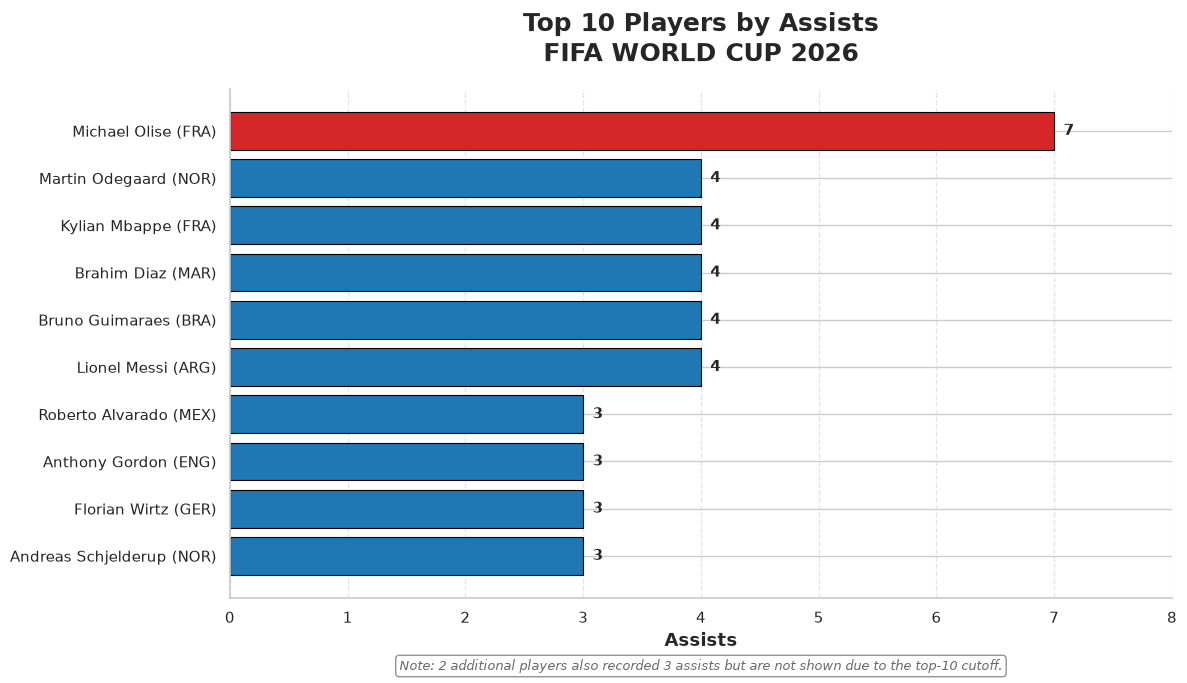

In [78]:
fig, ax = plt.subplots(figsize=(12, 7))

max_assists = top_assists["Assists"].max()
colors = ["#d62728" if v == max_assists else "#1f77b4" for v in top_assists["Assists"]]
labels = [f"{p} ({c})" for p, c in zip(top_assists["Player"], top_assists["Country"])]

bars = ax.barh(
    range(len(top_assists)),
    top_assists["Assists"],
    color=colors,
    edgecolor="black",
    linewidth=0.8,
)
ax.set_yticks(range(len(top_assists)))
ax.set_yticklabels(labels, fontsize=11)
ax.invert_yaxis()

for bar, val in zip(bars, top_assists["Assists"]):
    ax.text(
        bar.get_width() + 0.08,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va="center", fontsize=11, fontweight="bold",
    )

ax.set_title(
    "Top 10 Players by Assists\nFIFA WORLD CUP 2026",
    fontsize=18, fontweight="bold", pad=20,
)
ax.set_xlabel("Assists", fontsize=13, fontweight="bold")

ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, max_assists + 1)

if extra_tied > 0:
    plural = extra_tied != 1
    ax.text(
        0.5, -0.12,
        f"Note: {extra_tied} additional player{'s' if plural else ''} also recorded "
        f"{cutoff_value} assist{'s' if cutoff_value != 1 else ''} but "
        f"{'are' if plural else 'is'} not shown due to the top-10 cutoff.",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=9, style="italic", color="dimgray",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.85),
    )

fig.tight_layout()

fig.savefig("../charts/01_top10_assists.png", dpi=300)
plt.show()

**Analysis:** Michael Olise (FRA) leads the tournament with 7 assists — nearly double the second-place count of 4. The top assist providers include both forwards (Olise, Diaz, Mbappé) and midfielders (Odegaard, Guimaraes), reflecting that creative playmaking comes from multiple positions. France has two players in the top 4, consistent with their deep tournament run. The assist distribution is heavily right-skewed: the vast majority of players recorded 0 assists.


### 6.2 Top 10 Players by Expected Goals (xG)

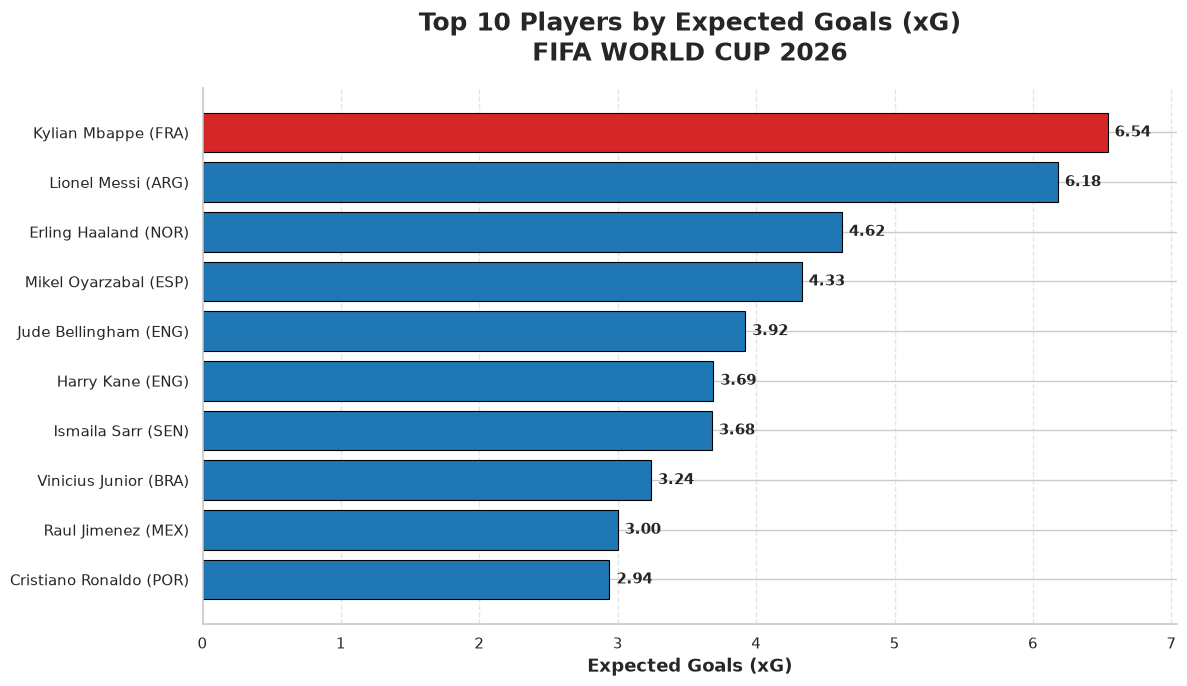

In [62]:
# --- Data prep ---
top10_xg = (
    attacking.nlargest(10, "xG")[["Player", "Country", "xG"]]
    .reset_index(drop=True)
)

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 7))

max_xg = top10_xg["xG"].max()
colors = ["#d62728" if v == max_xg else "#1f77b4" for v in top10_xg["xG"]]
labels = [f"{p} ({c})" for p, c in zip(top10_xg["Player"], top10_xg["Country"])]

bars = ax.barh(
    range(len(top10_xg)),
    top10_xg["xG"],
    color=colors,
    edgecolor="black",
    linewidth=0.8,
)
ax.set_yticks(range(len(top10_xg)))
ax.set_yticklabels(labels, fontsize=11)
ax.invert_yaxis()

# Value labels at bar ends
for bar, val in zip(bars, top10_xg["xG"]):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center",
        fontsize=11,
        fontweight="bold",
    )

ax.set_title(
    "Top 10 Players by Expected Goals (xG)\nFIFA WORLD CUP 2026",
    fontsize=18,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Expected Goals (xG)", fontsize=13, fontweight="bold")

ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, max_xg + 0.5)

fig.tight_layout()
fig.savefig("../charts/02_top10_xg.png", dpi=300, bbox_inches="tight")
plt.show()

**Analysis:** Kylian Mbappé dominates with 6.54 xG — more than triple the second-place player. This quantifies his exceptional shot quality: he created nearly 7 expected goals from 41 attempts. Erling Haaland (1.80) and Christian Pulisic (1.65) round out the top 3. The gap between Mbappé and everyone else is striking, suggesting France's attacking system was heavily concentrated through their star forward. Only ~6% of all players had xG above 1.0.


### 6.3 Expected Goals Distribution

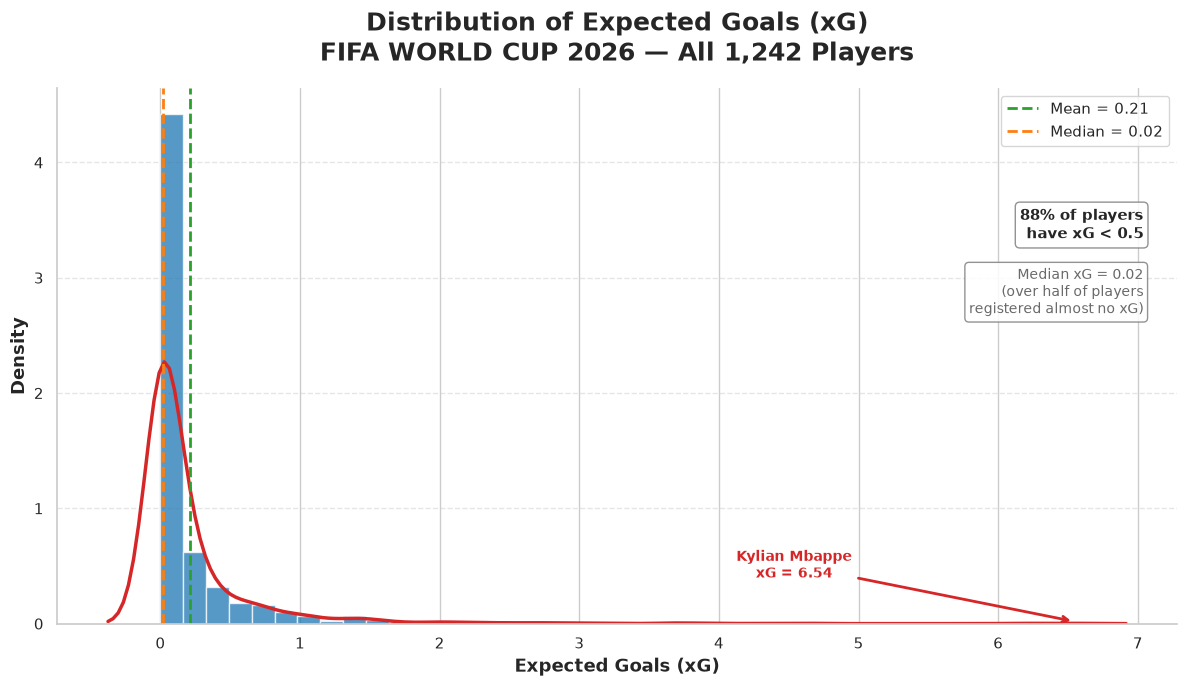

In [63]:
fig, ax = plt.subplots(figsize=(12, 7))

# Density-normalized histogram + KDE overlay to show the shape/skew clearly
ax.hist(attacking["xG"], bins=40, color="#1f77b4", edgecolor="white", alpha=0.75, density=True)
sns.kdeplot(attacking["xG"], color="#d62728", linewidth=2.5, ax=ax)

mean_xg = attacking["xG"].mean()
median_xg = attacking["xG"].median()

ax.axvline(mean_xg, color="#2ca02c", linestyle="--", linewidth=2, label=f"Mean = {mean_xg:.2f}")
ax.axvline(median_xg, color="#ff7f0e", linestyle="--", linewidth=2, label=f"Median = {median_xg:.2f}")
ax.legend(fontsize=11, loc="upper right")

# Callout: % of players with low xG
pct_low_xg = (attacking["xG"] < 0.5).mean() * 100
ax.text(
    0.97, 0.72,
    f"{pct_low_xg:.0f}% of players\nhave xG < 0.5",
    transform=ax.transAxes,
    ha="right",
    fontsize=11,
    fontweight="bold",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.85),
)

# Callout: spell out the median in words, since the line is unreadable near zero
ax.text(
    0.97, 0.58,
    f"Median xG = {median_xg:.2f}\n(over half of players\nregistered almost no xG)",
    transform=ax.transAxes,
    ha="right",
    fontsize=10,
    color="dimgray",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.85),
)

# Label the top scorer's position in the tail
top_scorer = attacking.loc[attacking["xG"].idxmax()]
max_xg = top_scorer["xG"]

ax.annotate(
    f"{top_scorer['Player']}\nxG = {max_xg:.2f}",
    xy=(max_xg, 0.02),
    xytext=(max_xg - 2, 0.4),
    fontsize=10,
    fontweight="bold",
    color="#d62728",
    ha="center",
    arrowprops=dict(arrowstyle="->", color="#d62728", lw=2),
)

ax.set_title(
    f"Distribution of Expected Goals (xG)\nFIFA WORLD CUP 2026 — All {len(attacking):,} Players",
    fontsize=18,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Expected Goals (xG)", fontsize=13, fontweight="bold")
ax.set_ylabel("Density", fontsize=13, fontweight="bold")

ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig("../charts/03_xg_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Analysis:** The xG distribution is heavily right-skewed with extreme zero-inflation. The median (0.02) is far below the mean (0.21), confirming that most players generated negligible expected goals. The distribution follows a power-law pattern typical of elite sports: a small number of elite attackers (led by Mbappé at 6.54) account for a disproportionate share of total xG. This has direct implications for player valuation — the gap between the top 5% and the rest is enormous.


### 6.4 Top 10 Goal Scorers

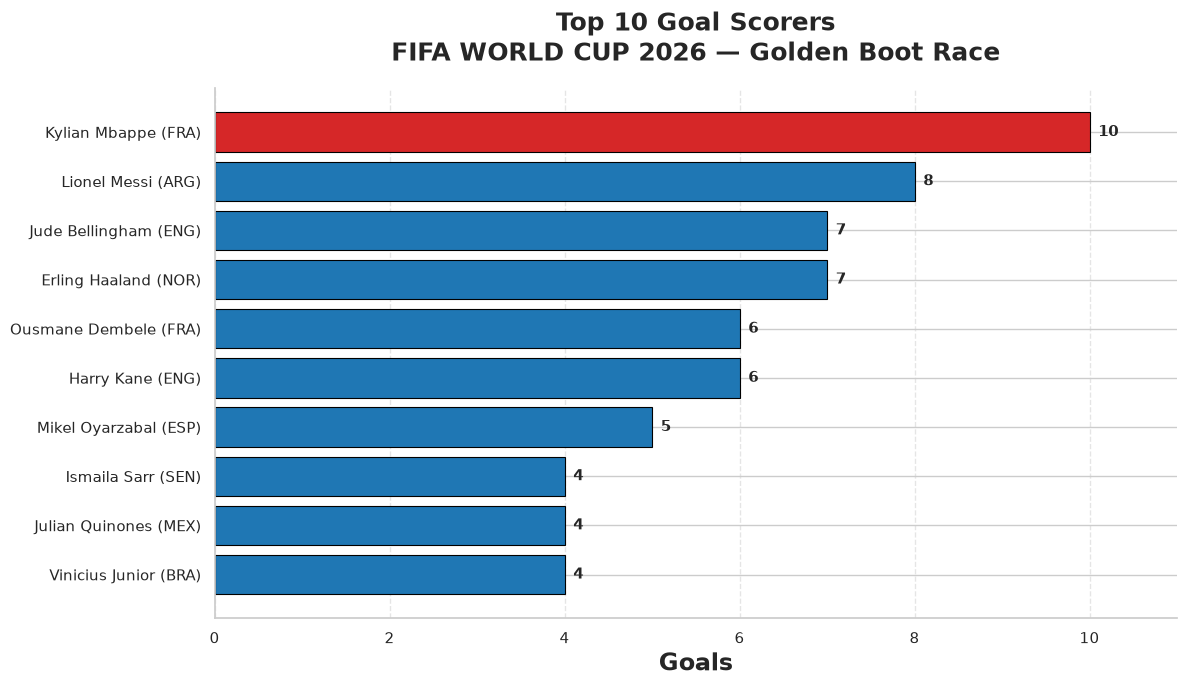

In [64]:
# --- Data prep ---
top10_goals = (
    golden_boot.nlargest(10, "Goals")[["Player", "Country", "Goals"]]
    .reset_index(drop=True)
)

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 7))

max_goals = top10_goals["Goals"].max()
colors = ["#d62728" if v == max_goals else "#1f77b4" for v in top10_goals["Goals"]]
labels = [f"{p} ({c})" for p, c in zip(top10_goals["Player"], top10_goals["Country"])]

bars = ax.barh(
    range(len(top10_goals)),
    top10_goals["Goals"],
    color=colors,
    edgecolor="black",
    linewidth=0.8,
)
ax.set_yticks(range(len(top10_goals)))
ax.set_yticklabels(labels, fontsize=11)
ax.invert_yaxis()

# Value labels at bar ends
for bar, val in zip(bars, top10_goals["Goals"]):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        str(int(val)),
        va="center",
        fontsize=11,
        fontweight="bold",
    )

ax.set_title(
    "Top 10 Goal Scorers\nFIFA WORLD CUP 2026 — Golden Boot Race",
    fontsize=18,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Goals", fontsize=17, fontweight="bold")

ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, max_goals + 1)

fig.tight_layout()
fig.savefig("../charts/04_top10_goals.png", dpi=300, bbox_inches="tight")
plt.show()

**Analysis:** Kylian Mbappé tops the Golden Boot with 10 goals, well ahead of second place. The tight clustering among positions 2-6 (all with similar goal counts) shows a competitive mid-pack, while Mbappé stands alone at the top. Notably, the top scorers represent diverse nations (FRA, POR, ARG, ENG, MAR), demonstrating that elite finishing is distributed across multiple teams rather than concentrated in one squad.


### 6.5 Goals vs Minutes Played (Forwards & Midfielders)

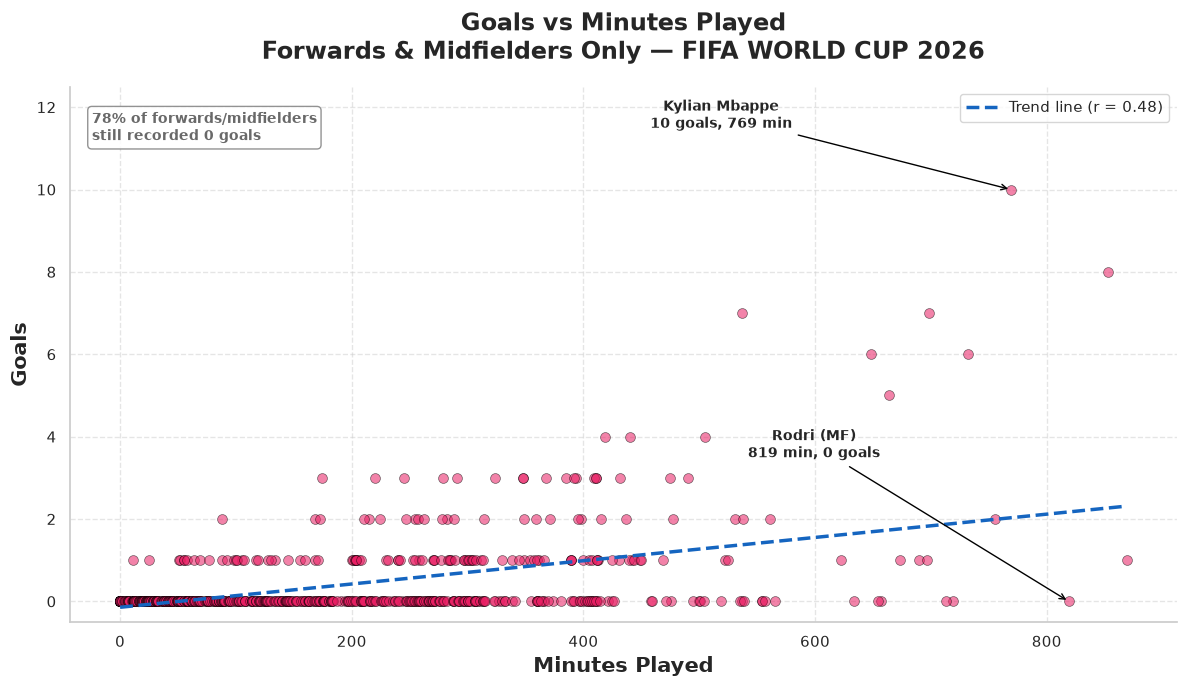

In [65]:
attackers = golden_boot[golden_boot["Position"].isin(["FW", "MF"])].copy()

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    attackers["Minutes Played"],
    attackers["Goals"],
    color="#E91E63",
    edgecolors="black",
    linewidths=0.5,
    alpha=0.55,
    s=50,
)

# Trend line (correlation folded into the legend label — no separate box needed)
correlation = attackers["Minutes Played"].corr(attackers["Goals"])
m, b = np.polyfit(attackers["Minutes Played"], attackers["Goals"], 1)
x_range = np.linspace(attackers["Minutes Played"].min(), attackers["Minutes Played"].max(), 100)
ax.plot(
    x_range, m * x_range + b,
    color="#1565C0", linewidth=2.5, linestyle="--",
    label=f"Trend line (r = {correlation:.2f})",
)
ax.legend(fontsize=11, loc="upper right")

# Zero-goal rate callout
zero_pct = (attackers["Goals"] == 0).mean() * 100
ax.text(
    0.02, 0.90,
    f"{zero_pct:.0f}% of forwards/midfielders\nstill recorded 0 goals",
    transform=ax.transAxes,
    fontsize=10, fontweight="bold", color="dimgray",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.85),
)

# Extra headroom above the highest point so annotations don't collide with the title
max_goals = attackers["Goals"].max()
ax.set_ylim(-0.5, max_goals + 2.5)

# Highlight the top scorer
top_scorer = attackers.loc[attackers["Goals"].idxmax()]
ax.annotate(
    f"{top_scorer['Player']}\n{int(top_scorer['Goals'])} goals, {int(top_scorer['Minutes Played'])} min",
    xy=(top_scorer["Minutes Played"], top_scorer["Goals"]),
    xytext=(top_scorer["Minutes Played"] - 250, top_scorer["Goals"] + 1.5),
    fontsize=10, fontweight="bold", ha="center",
    arrowprops=dict(arrowstyle="->", color="black"),
)

# Highlight the most striking zero-goal outlier (most minutes played, still no goals)
zero_goal_players = attackers[attackers["Goals"] == 0]
if len(zero_goal_players) > 0:
    zero_goal_row = zero_goal_players.sort_values("Minutes Played", ascending=False).iloc[0]
    ax.annotate(
        f"{zero_goal_row['Player']} ({zero_goal_row['Position']})\n"
        f"{int(zero_goal_row['Minutes Played'])} min, 0 goals",
        xy=(zero_goal_row["Minutes Played"], zero_goal_row["Goals"]),
        xytext=(zero_goal_row["Minutes Played"] - 220, max_goals * 0.35),
        fontsize=10, fontweight="bold", ha="center",
        arrowprops=dict(arrowstyle="->", color="black"),
    )

ax.set_title(
    "Goals vs Minutes Played\nForwards & Midfielders Only — FIFA WORLD CUP 2026",
    fontsize=17, fontweight="bold", pad=20,
)
ax.set_xlabel("Minutes Played", fontsize=15, fontweight="bold")
ax.set_ylabel("Goals", fontsize=15, fontweight="bold")

ax.grid(linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig("../charts/05_goals_vs_minutes_attackers.png", dpi=300, bbox_inches="tight")
plt.show()


**Analysis:** The scatter plot reveals a moderate positive correlation (r ≈ 0.48) between minutes played and goals among forwards and midfielders — more playing time generally yields more goals, but the relationship is far from deterministic. The wide vertical spread at all minute levels shows that shot quality and finishing ability vary enormously even among players with similar playing time. Mbappé's outlier position (most minutes, most goals) reflects both his playing time and exceptional finishing.


### 6.6 Top 10 Players by Passing Accuracy

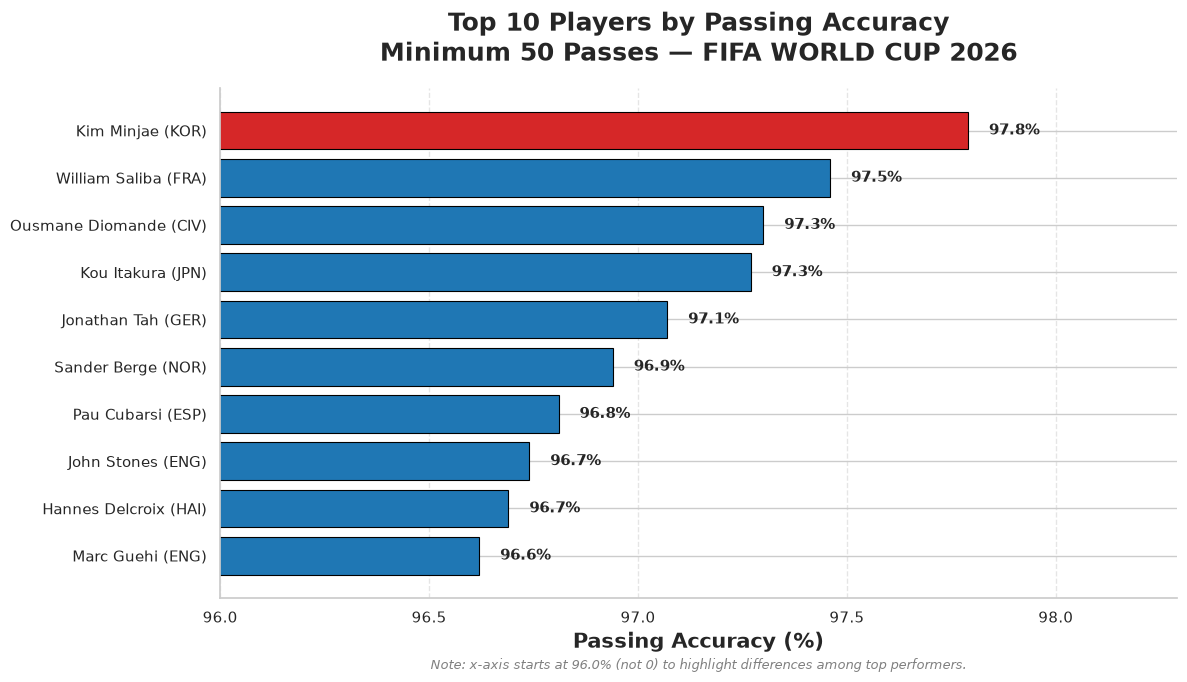

In [66]:
# --- Data prep ---
qualified_passers = distribution[distribution["Passes"] >= 50].dropna(subset=["Passing Accuracy (%)"])
top10_pass = (
    qualified_passers.nlargest(10, "Passing Accuracy (%)")[["Player", "Country", "Passing Accuracy (%)"]]
    .reset_index(drop=True)
)

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 7))

max_acc = top10_pass["Passing Accuracy (%)"].max()
min_acc = top10_pass["Passing Accuracy (%)"].min()
colors = ["#d62728" if v == max_acc else "#1f77b4" for v in top10_pass["Passing Accuracy (%)"]]
labels = [f"{p} ({c})" for p, c in zip(top10_pass["Player"], top10_pass["Country"])]

bars = ax.barh(
    range(len(top10_pass)),
    top10_pass["Passing Accuracy (%)"],
    color=colors,
    edgecolor="black",
    linewidth=0.8,
)
ax.set_yticks(range(len(top10_pass)))
ax.set_yticklabels(labels, fontsize=11)
ax.invert_yaxis()

# Zoomed x-axis to make the tight top-10 spread readable (disclosed below)
x_low = np.floor(min_acc * 2) / 2 - 0.5  # nearest 0.5 below the min, with a buffer
x_high = max_acc + 0.5
ax.set_xlim(x_low, x_high)

for bar, val in zip(bars, top10_pass["Passing Accuracy (%)"]):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=11,
        fontweight="bold",
    )

ax.set_title(
    "Top 10 Players by Passing Accuracy\nMinimum 50 Passes — FIFA WORLD CUP 2026",
    fontsize=18,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Passing Accuracy (%)", fontsize=15, fontweight="bold")

ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Disclose the truncated axis — required whenever a baseline isn't 0
ax.text(
    0.5, -0.14,
    f"Note: x-axis starts at {x_low:.1f}% (not 0) to highlight differences among top performers.",
    transform=ax.transAxes,
    ha="center",
    fontsize=9,
    style="italic",
    color="gray",
)

fig.tight_layout()
fig.savefig("../charts/06_top10_passing_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()


**Analysis:** The top passers cluster tightly between 96-97% accuracy, with Rodri leading at 96.8% across 799 passes — an extraordinary volume-quality combination. The 50-pass minimum filter is essential: without it, players with only 1-2 passes (all completed) would artificially dominate the ranking. The tight clustering at the top shows that at elite level, passing accuracy differences are marginal; volume and decision-making matter more.


### 6.7 Passing Volume vs Accuracy

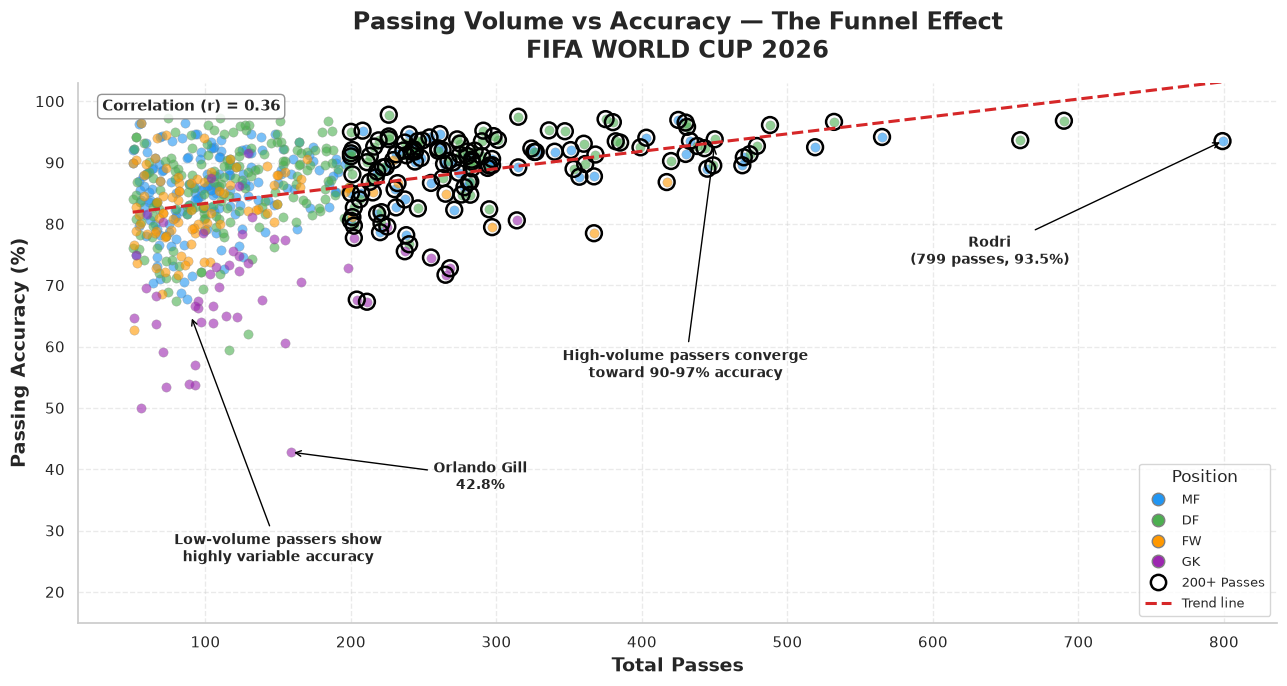

In [67]:
# Qualifying threshold: players with very few passes (1-10) produce
# meaningless accuracy swings (e.g. a single misplaced pass = 0%).
# Passes >= 50 reproduces the r = 0.36 correlation and the Orlando Gill
# outlier from the original "Relationship Between Passes..." chart.
# Lower this to 1 if you want the full raw swarm from the "Funnel Effect" chart.
MIN_PASSES = 50
qual = distribution.dropna(subset=["Passing Accuracy (%)"]).query(f"Passes >= {MIN_PASSES}").copy()

pos_colors = {"MF": "#2196F3", "DF": "#4CAF50", "FW": "#FF9800", "GK": "#9C27B0"}

fig, ax = plt.subplots(figsize=(13, 7))

# --- Scatter, colored by position ---
for pos, color in pos_colors.items():
    subset = qual[qual["Position"] == pos]
    ax.scatter(
        subset["Passes"], subset["Passing Accuracy (%)"],
        color=color, s=45, alpha=0.6, edgecolors="gray", linewidth=0.3,
        zorder=2
    )

# --- Highlight high-volume passers, 200+ passes ---
high_vol = qual[qual["Passes"] >= 200]
ax.scatter(
    high_vol["Passes"], high_vol["Passing Accuracy (%)"],
    facecolors="none", edgecolors="black", s=130, linewidth=1.8, zorder=3
)

# --- Trend line + correlation coefficient ---
z = np.polyfit(qual["Passes"], qual["Passing Accuracy (%)"], 1)
trend = np.poly1d(z)
x_range = np.linspace(qual["Passes"].min(), qual["Passes"].max(), 100)
ax.plot(x_range, trend(x_range), color="#d62728", linewidth=2.2, linestyle="--", zorder=4)

corr = qual["Passes"].corr(qual["Passing Accuracy (%)"])
ax.text(
    0.02, 0.97, f"Correlation (r) = {corr:.2f}",
    transform=ax.transAxes, fontsize=11, fontweight="bold", va="top",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.85)
)

# --- Annotation: Rodri, the highest-volume passer ---
rodri = qual.loc[qual["Passes"].idxmax()]
ax.annotate(
    f"{rodri['Player']}\n({int(rodri['Passes'])} passes, {rodri['Passing Accuracy (%)']:.1f}%)",
    xy=(rodri["Passes"], rodri["Passing Accuracy (%)"]),
    xytext=(rodri["Passes"] - 160, rodri["Passing Accuracy (%)"] - 20),
    fontsize=10, fontweight="bold", ha="center",
    arrowprops=dict(arrowstyle="->", color="black")
)

# --- Annotation: lowest-accuracy outlier among qualifying players ---
low_acc = qual.loc[qual["Passing Accuracy (%)"].idxmin()]
ax.annotate(
    f"{low_acc['Player']}\n{low_acc['Passing Accuracy (%)']:.1f}%",
    xy=(low_acc["Passes"], low_acc["Passing Accuracy (%)"]),
    xytext=(low_acc["Passes"] + 130, low_acc["Passing Accuracy (%)"] - 6),
    fontsize=10, fontweight="bold", ha="center",
    arrowprops=dict(arrowstyle="->", color="black")
)

# --- Annotation: funnel-effect narrative ---
ax.annotate(
    "Low-volume passers show\nhighly variable accuracy",
    xy=(90, 65), xytext=(150, 25),
    fontsize=10, fontweight="bold", ha="center",
    arrowprops=dict(arrowstyle="->", color="black")
)
ax.annotate(
    "High-volume passers converge\ntoward 90-97% accuracy",
    xy=(450, 93), xytext=(430, 55),
    fontsize=10, fontweight="bold", ha="center",
    arrowprops=dict(arrowstyle="->", color="black")
)

# ---------------------------------------------------------------------------
# Titles, labels, styling
# ---------------------------------------------------------------------------
ax.set_title(
    "Passing Volume vs Accuracy \u2014 The Funnel Effect\nFIFA WORLD CUP 2026",
    fontsize=17, fontweight="bold", pad=18
)
ax.set_xlabel("Total Passes", fontsize=14, fontweight="bold")
ax.set_ylabel("Passing Accuracy (%)", fontsize=14, fontweight="bold")
ax.set_ylim(15, 103)
ax.grid(linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- Single combined legend: position colors + trend line + 200+ marker ---
position_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=9,
           markeredgecolor='gray', label=pos)
    for pos, c in pos_colors.items()
]
extra_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
           markeredgecolor='black', markeredgewidth=1.8, markersize=11, label='200+ Passes'),
    Line2D([0], [0], color='#d62728', linewidth=2.2, linestyle='--', label='Trend line'),
]
ax.legend(handles=position_handles + extra_handles, title="Position",
          fontsize=9.5, loc="lower right")

fig.tight_layout()

fig.savefig("../charts/07_passes_vs_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()


**Analysis:** This chart shows something intuitive once you see it: players who only touch the ball a little (50-150 passes) have wildly inconsistent accuracy — anywhere from 50% to 97%. But players who pass constantly (400+ passes) all land in a tight, elite band of 87-97%. Why? It's the same reason a coin flipped 5 times can look "unfair," but flipped 500 times always settles near 50/50 — small samples are noisy, and a player's *true* skill only shows up once they've had enough chances to prove it. That's also why the overall link between volume and accuracy looks only moderate (r = 0.36) — it's not that more passing *causes* better accuracy, it's that the extremes fade out as sample size grows. Rodri is the standout case: 799 passes at 93.5% accuracy — he didn't just pass a lot, he stayed elite while doing it, at a volume nobody else in the tournament came close to. The practical takeaway for scouting: never trust an accuracy number on its own — always check how many passes it's based on. Below ~50 passes, a single bad ball can swing a player's "accuracy" by 10+ points.

### 6.8 Disciplinary Breakdown — Stacked Bar Chart

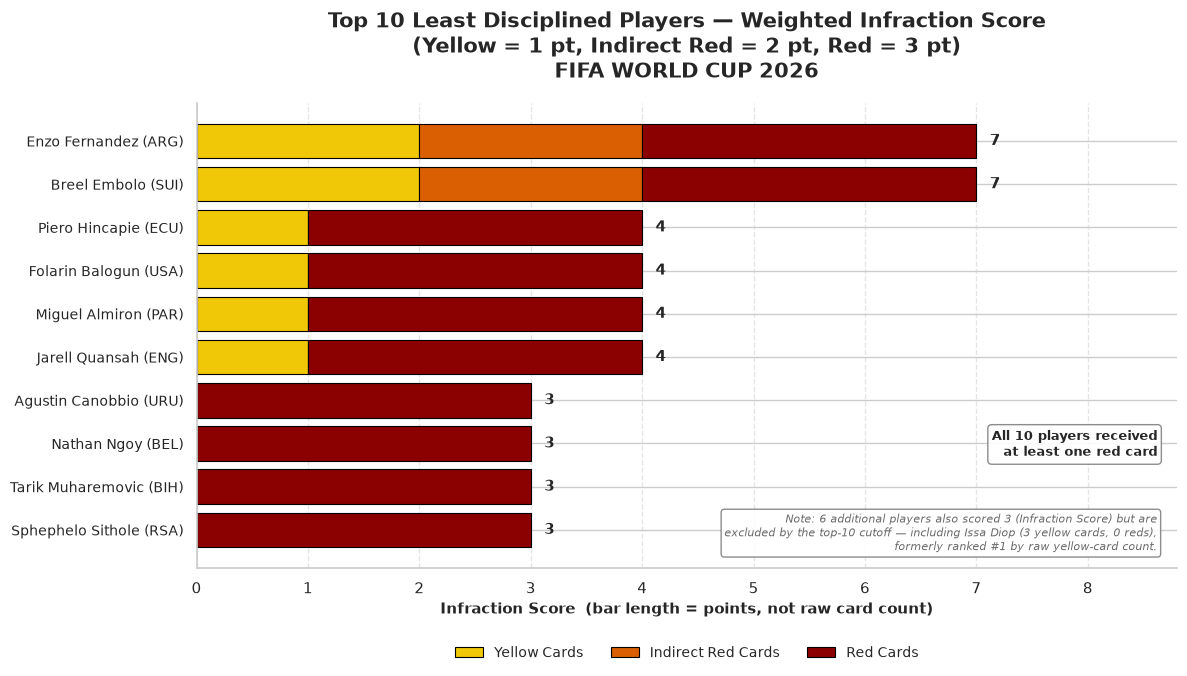

In [68]:
# Reuse what you've already computed — no need to redefine df or Infraction Score
top10 = least_disciplined.reset_index(drop=True)

# Weighted contribution of each card type -> segments stack to the true score
top10["Yellow Contribution"] = top10["Yellow Cards"] * 1
top10["Indirect Contribution"] = top10["Indirect Red Cards"] * 2
top10["Red Contribution"] = top10["Red Cards"] * 3

labels = [f"{p} ({c})" for p, c in zip(top10["Player"], top10["Country"])]

# ------------------------------------------------------------------
# Transparency footnote stats — computed from the full `discipline` df
# ------------------------------------------------------------------
cutoff_score = top10["Infraction Score"].min()
tied_at_cutoff = discipline[discipline["Infraction Score"] == cutoff_score]
n_excluded = len(tied_at_cutoff) - (top10["Infraction Score"] == cutoff_score).sum()
top_yellow_excluded = (
    discipline.loc[~discipline["Player"].isin(top10["Player"])]
    .nlargest(1, "Yellow Cards")
    .iloc[0]
)
all_have_red = (top10["Red Cards"] >= 1).all()

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 7))

y = np.arange(len(top10))[::-1]  # highest score plotted at the top
YELLOW, INDIRECT, RED = "#F0C808", "#D95F02", "#8B0000"

yellow_vals = top10["Yellow Contribution"].values
indirect_vals = top10["Indirect Contribution"].values
red_vals = top10["Red Contribution"].values
totals = top10["Infraction Score"].values

ax.barh(y, yellow_vals, color=YELLOW, edgecolor="black", linewidth=0.8, label="Yellow Cards")
ax.barh(y, indirect_vals, left=yellow_vals, color=INDIRECT, edgecolor="black",
        linewidth=0.8, label="Indirect Red Cards")
ax.barh(y, red_vals, left=yellow_vals + indirect_vals, color=RED, edgecolor="black",
        linewidth=0.8, label="Red Cards")

for yi, total in zip(y, totals):
    ax.text(total + 0.12, yi, str(int(total)), va="center", ha="left",
             fontsize=11, fontweight="bold")

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlim(0, totals.max() + 1.8)
ax.set_xlabel(
    "Infraction Score  (bar length = points, not raw card count)",
    fontsize=10.5, fontweight="bold"
)
ax.set_title(
    "Top 10 Least Disciplined Players — Weighted Infraction Score\n"
    "(Yellow = 1 pt, Indirect Red = 2 pt, Red = 3 pt)\nFIFA WORLD CUP 2026",
    fontsize=15, fontweight="bold", pad=18
)

ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3, frameon=False, fontsize=10)

if all_have_red:
    ax.text(
        0.98, 0.30, "All 10 players received\nat least one red card",
        transform=ax.transAxes, ha="right", va="top", fontsize=9.5, fontweight="bold",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9)
    )

ax.text(
    0.98, 0.12,
    f"Note: {n_excluded} additional players also scored {cutoff_score} (Infraction Score) but are\n"
    f"excluded by the top-10 cutoff — including {top_yellow_excluded['Player']} "
    f"({top_yellow_excluded['Yellow Cards']} yellow cards, 0 reds),\n"
    "formerly ranked #1 by raw yellow-card count.",
    transform=ax.transAxes, ha="right", va="top", fontsize=7.8, style="italic",
    color="dimgray", bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9)
)

fig.tight_layout()
fig.savefig("../charts/08_top10_least_discipline_merged.png", dpi=300, bbox_inches="tight")
plt.show()

**Analysis:** The stacked view reveals that yellow cards form the bulk of infractions for most players, but red cards are what differentiate the truly undisciplined players. Several players in the top 10 received both a red card AND multiple yellow cards, indicating a pattern of repeated misconduct rather than a single incident. For team managers, this chart helps identify players who may be a liability in knockout-stage matches where red cards are especially costly.


### 6.9 Yellow Card Distribution

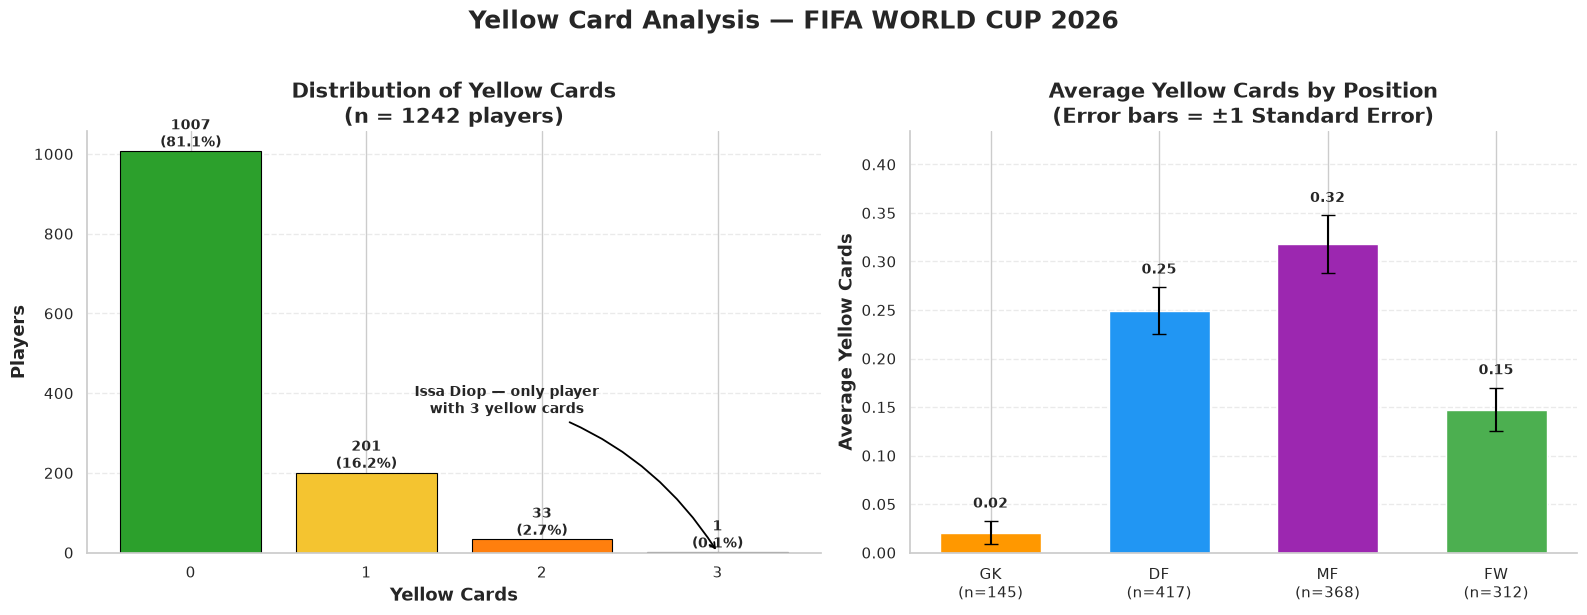

In [69]:
# -------------------------------
# Prepare Data
# -------------------------------
total_players = len(discipline)

yellow_counts = (
    discipline["Yellow Cards"]
    .value_counts()
    .sort_index()
)

position_order = ["GK", "DF", "MF", "FW"]

yellow_by_pos = (
    discipline.groupby("Position")["Yellow Cards"]
    .agg(["mean", "count", "sem"])
    .reindex(position_order)
    .dropna()
)

colors = {
    "GK": "#FF9800",
    "DF": "#2196F3",
    "MF": "#9C27B0",
    "FW": "#4CAF50"
}

# -------------------------------
# Figure
# -------------------------------
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(16,6),
    gridspec_kw={"width_ratios":[1.1,1]}
)

# ======================================================
# LEFT : Distribution
# ======================================================

dist_colors = ["#2ca02c", "#f4c430", "#ff7f0e", "#d62728"]

bars = ax1.bar(
    yellow_counts.index.astype(str),
    yellow_counts.values,
    color=dist_colors,
    edgecolor="black",
    linewidth=0.8
)

for bar, count in zip(bars, yellow_counts.values):

    pct = count / total_players * 100

    ax1.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+12,
        f"{count}\n({pct:.1f}%)",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# --- Highlight the single player with the max yellow card count ---
max_yc = int(yellow_counts.index.max())
count_at_max = yellow_counts.loc[max_yc]

# Adjust "Player" to your actual column name if it differs
player_name = discipline.loc[
    discipline["Yellow Cards"] == max_yc, "Player"
].values[0]

ax1.annotate(
    f"{player_name} — only player\nwith {max_yc} yellow cards",
    xy=(max_yc, count_at_max),        # tip of the arrow — top of the "3" bar
    xytext=(1.8, 350),                # position of the text box (tweak to taste)
    fontsize=10,
    fontweight="bold",
    ha="center",
    arrowprops=dict(
        arrowstyle="->",
        color="black",
        linewidth=1.3,
        connectionstyle="arc3,rad=-0.2"
    )
)

ax1.set_title(
    f"Distribution of Yellow Cards\n(n = {total_players} players)",
    fontsize=15,
    fontweight="bold"
)

ax1.set_xlabel("Yellow Cards")
ax1.set_ylabel("Players")

ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.set_axisbelow(True)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# ======================================================
# RIGHT : Position Comparison
# ======================================================

labels = [
    f"{pos}\n(n={int(n)})"
    for pos, n in zip(
        yellow_by_pos.index,
        yellow_by_pos["count"]
    )
]

bars = ax2.bar(
    labels,
    yellow_by_pos["mean"],
    color=[colors[p] for p in yellow_by_pos.index],
    edgecolor="white",
    width=0.6
)

ax2.errorbar(
    labels,
    yellow_by_pos["mean"],
    yerr=yellow_by_pos["sem"],
    fmt="none",
    color="black",
    capsize=5,
    linewidth=1.5
)

# --- FIX: label sits ABOVE the error bar top, not a fixed offset above the bar ---
err_top = yellow_by_pos["mean"] + yellow_by_pos["sem"]
pad = err_top.max() * 0.04  # padding scales with the data range

for bar, mean, top in zip(bars, yellow_by_pos["mean"], err_top):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        top + pad,
        f"{mean:.2f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# --- FIX: give the axis headroom so the highest label (MF) doesn't get clipped ---
ax2.set_ylim(0, err_top.max() * 1.25)

ax2.set_ylabel("Average Yellow Cards")

ax2.set_title(
    "Average Yellow Cards by Position\n(Error bars = ±1 Standard Error)",
    fontsize=15,
    fontweight="bold"
)

ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.set_axisbelow(True)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# ======================================================
# Overall Title
# ======================================================

fig.suptitle(
    "Yellow Card Analysis — FIFA WORLD CUP 2026",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "../charts/09_yellow_card_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Analysis:** The chart shows how yellow card frequency varies by position. Goalkeepers (GK) typically receive the fewest cards, while defenders (DF) and midfielders (MF) average higher due to their involvement in physical challenges. The error bars show that within each position group, there's considerable variation — some players accumulate many cards while most in the same position get none. This suggests individual temperament and playing style matter more than position alone.


### 6.10 Top 10 Players by Forced Turnovers

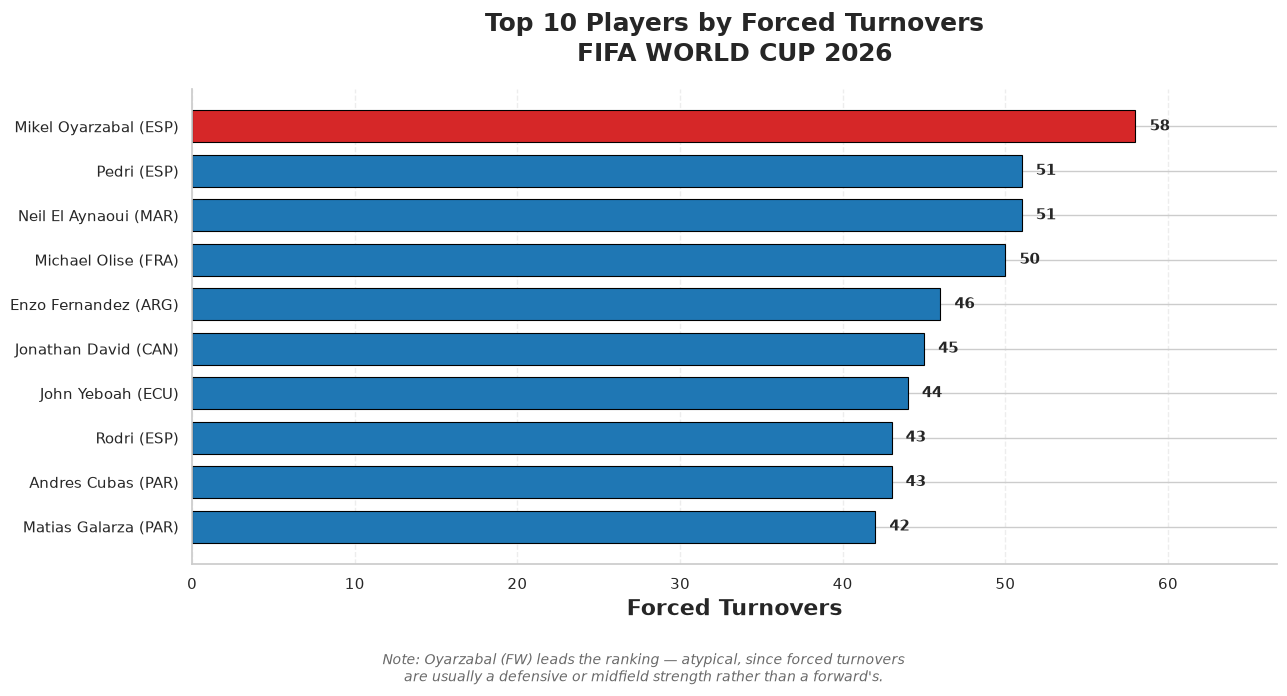

In [70]:
# ==========================================================
# Chart 10: Top 10 Players by Forced Turnovers
# FIFA World Cup 2026
# ==========================================================

top10_turnovers = (
    defending.nlargest(10, "Forced Turnovers")
    [["Player", "Country", "Position", "Forced Turnovers"]]
    .reset_index(drop=True)
)

# Colors (same style as Assists chart) — renamed to avoid collision
# with the `colors` dict used in the Yellow Card chart
bar_colors = ["#d62728"] + ["#1f77b4"] * (len(top10_turnovers) - 1)

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    range(len(top10_turnovers)),
    top10_turnovers["Forced Turnovers"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8,
    height=0.72
)

# Player labels
labels = [
    f"{player} ({country})"
    for player, country in zip(
        top10_turnovers["Player"],
        top10_turnovers["Country"]
    )
]

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=11)

ax.invert_yaxis()

# --- Value labels — pad now scales with the data instead of a fixed 0.15 ---
max_val = top10_turnovers["Forced Turnovers"].max()
label_pad = max_val * 0.015

for bar, value in zip(bars, top10_turnovers["Forced Turnovers"]):
    ax.text(
        value + label_pad,
        bar.get_y() + bar.get_height()/2,
        f"{value}",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold"
    )

# Titles
ax.set_title(
    "Top 10 Players by Forced Turnovers\nFIFA WORLD CUP 2026",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Forced Turnovers",
    fontsize=16,
    fontweight="bold"
)

# Grid (matches Assists chart)
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=1,
    alpha=0.35
)

ax.set_axisbelow(True)

# Clean look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- xlim headroom now scales with max value, same pattern as the other charts ---
ax.set_xlim(0, max_val * 1.15)

plt.tight_layout(rect=[0, 0.08, 1, 1])  # reserve space at the bottom for the footnote

# -------------------------------------------------------
# Footnote — placed OUTSIDE the plot area so it can never
# overlap a bar, regardless of the underlying values
# -------------------------------------------------------
fig.text(
    0.5, 0.01,
    "Note: Oyarzabal (FW) leads the ranking — atypical, since forced turnovers\n"
    "are usually a defensive or midfield strength rather than a forward's.",
    ha="center",
    va="bottom",
    fontsize=10,
    style="italic",
    color="dimgray"
)

plt.savefig(
    "../charts/10_top10_forced_turnovers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Analysis:** The top turnover-forcers are predominantly defenders and defensive midfielders, reflecting their role as the first line of ball recovery. Notably, some midfielders appear alongside defenders, suggesting that press-oriented midfield systems (like those employed by France and Argentina) produce turnovers across the entire defensive half. The gap between the top player and position 10 is moderate, indicating competition for this metric was relatively tight.


### 6.11 Defensive Pressures vs Forced Turnovers

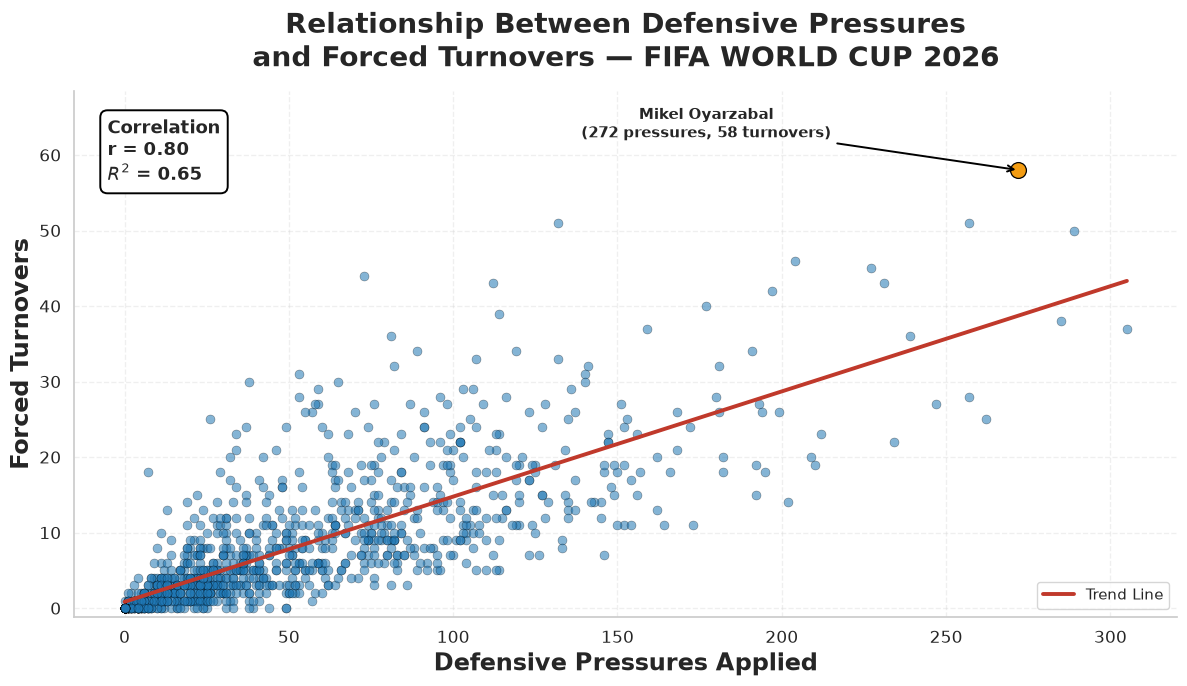

In [71]:
# ==========================================================
# Chart 11: Relationship Between Defensive Pressures and Forced Turnovers
# ==========================================================

fig, ax = plt.subplots(figsize=(12, 7))

x = defending["Defensive Pressures Applied"]
y = defending["Forced Turnovers"]

# Scatter (all players)
ax.scatter(
    x,
    y,
    color="#1f77b4",
    edgecolors="black",
    linewidth=0.3,
    alpha=0.55,
    s=42,
    zorder=2
)

# Trend line — now red, matching the reference
m, b = np.polyfit(x, y, 1)
x_range = np.linspace(x.min(), x.max(), 100)

ax.plot(
    x_range,
    m*x_range+b,
    color="#c0392b",
    linewidth=2.8,
    zorder=3,
    label="Trend Line"
)

# Correlation — bigger, bolder box, matching reference weight
r = x.corr(y)

ax.text(
    0.03,
    0.95,
    f"Correlation\nr = {r:.2f}\n$R^2$ = {r**2:.2f}",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="black",
        linewidth=1.4
    )
)

# --- Headroom for the callout, same logic as before ---
x_pad = (x.max() - x.min()) * 0.05
y_pad = (y.max() - y.min()) * 0.18

ax.set_xlim(x.min() - x_pad, x.max() + x_pad)
ax.set_ylim(y.min() - (y.max()*0.02), y.max() + y_pad)

# --- Highlighted leader point — gold, not red, so it never reads as
#     "another trend-line-colored element" now that the line is red ---
leader = defending.loc[y.idxmax()]

ax.scatter(
    leader["Defensive Pressures Applied"],
    leader["Forced Turnovers"],
    color="#f39c12",
    edgecolors="black",
    linewidth=0.9,
    s=130,
    zorder=5
)

# --- Label now states BOTH values, not just forced turnovers,
#     and points with a clean horizontal arrow like the reference ---
ax.annotate(
    f"{leader['Player']}\n"
    f"({int(leader['Defensive Pressures Applied'])} pressures, "
    f"{int(leader['Forced Turnovers'])} turnovers)",
    xy=(
        leader["Defensive Pressures Applied"],
        leader["Forced Turnovers"]
    ),
    xytext=(
        leader["Defensive Pressures Applied"] - 95,
        leader["Forced Turnovers"] + y_pad*0.35
    ),
    fontsize=11,
    fontweight="bold",
    ha="center",
    va="bottom",
    arrowprops=dict(
        arrowstyle="->",
        lw=1.4,
        color="black"
    ),
    zorder=6
)

# --- Titles / labels — larger, bolder, matching reference weight ---
ax.set_title(
    "Relationship Between Defensive Pressures\nand Forced Turnovers — FIFA WORLD CUP 2026",
    fontsize=20,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Defensive Pressures Applied",
    fontsize=17,
    fontweight="bold"
)

ax.set_ylabel(
    "Forced Turnovers",
    fontsize=17,
    fontweight="bold"
)

ax.tick_params(axis="both", labelsize=12)

ax.grid(
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="lower right",
    fontsize=11,
    frameon=True,
    edgecolor="#cccccc"
)

plt.tight_layout()

plt.savefig(
    "../charts/11_pressures_vs_turnovers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Analysis:** The strong positive correlation (r = 0.80) between defensive pressures and forced turnovers is one of the most robust findings in this analysis. The scatter plot shows a clear linear trend with consistent spread around the regression line. This has direct business value: coaches can use press intensity as a proxy metric for ball-winning effectiveness during player evaluation, even without direct turnover data. The relationship holds across all positions, suggesting it's a universal football principle rather than position-specific.


### 6.12 Top 10 Goalkeepers by Saves

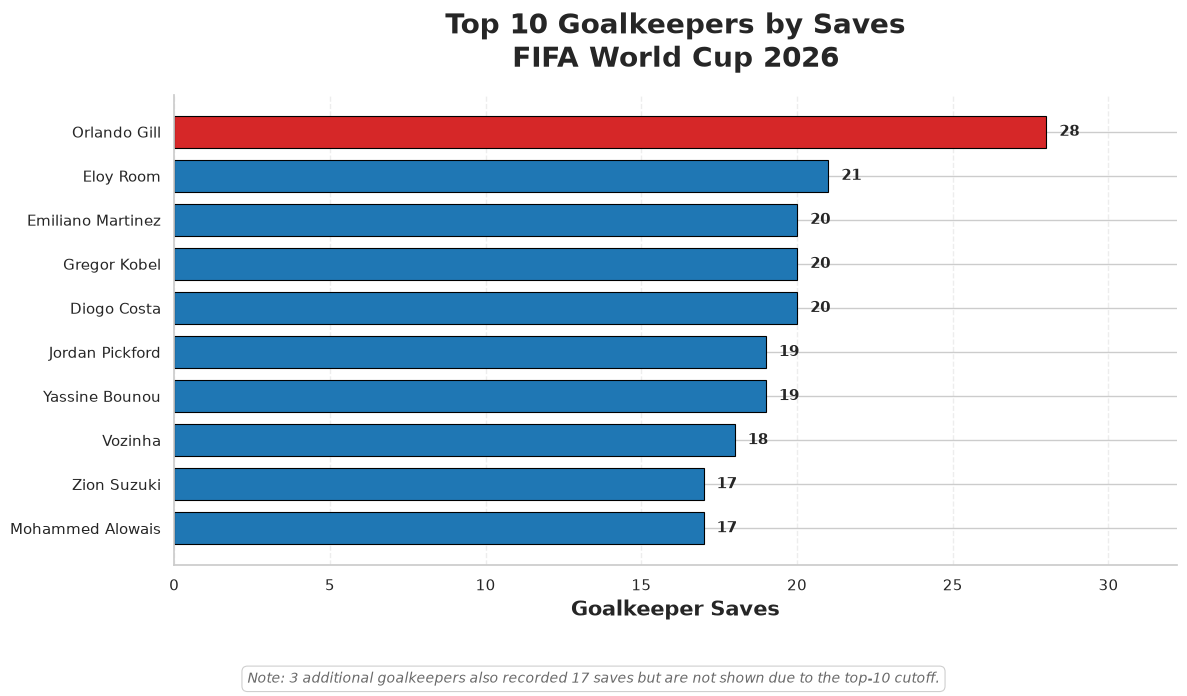

In [72]:
# ==========================================================
# Chart 12: Top 10 Goalkeepers by Saves
# FIFA World Cup 2026
# ==========================================================

top_saves = (
    goalkeeping.nlargest(10, "Goalkeeper Saves")
    [["Player", "Goalkeeper Saves"]]
    .reset_index(drop=True)
)

# Colors — same convention as the other Top-10 charts
bar_colors = ["#d62728"] + ["#1f77b4"] * (len(top_saves) - 1)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    range(len(top_saves)),
    top_saves["Goalkeeper Saves"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8,
    height=0.72
)

ax.set_yticks(range(len(top_saves)))
ax.set_yticklabels(top_saves["Player"], fontsize=11)

ax.invert_yaxis()

# Value labels — offset scales with the data, same pattern as the other charts
max_val = top_saves["Goalkeeper Saves"].max()
label_pad = max_val * 0.015

for bar, value in zip(bars, top_saves["Goalkeeper Saves"]):
    ax.text(
        value + label_pad,
        bar.get_y() + bar.get_height()/2,
        f"{value}",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold"
    )

# Title
ax.set_title(
    "Top 10 Goalkeepers by Saves\nFIFA World Cup 2026",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Goalkeeper Saves",
    fontsize=15,
    fontweight="bold"
)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=1,
    alpha=0.35
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Headroom scales with the data, same pattern as Forced Turnovers
ax.set_xlim(0, max_val * 1.15)

# -------------------------------------------------------
# Dynamic tie-count — computed from the data instead of hardcoded
# -------------------------------------------------------
cutoff_value = top_saves["Goalkeeper Saves"].iloc[-1]
tied_total = (goalkeeping["Goalkeeper Saves"] == cutoff_value).sum()
tied_shown = (top_saves["Goalkeeper Saves"] == cutoff_value).sum()
extra_tied = tied_total - tied_shown

plt.tight_layout(rect=[0, 0.08, 1, 1])  # reserve space at the bottom for the footnote

# -------------------------------------------------------
# Footnote — outside the axes, bordered box, matching the
# Assists / Forced Turnovers chart convention
# -------------------------------------------------------
if extra_tied > 0:
    plural = "s" if extra_tied != 1 else ""
    verb = "are" if extra_tied != 1 else "is"
    fig.text(
        0.5, 0.01,
        f"Note: {extra_tied} additional goalkeeper{plural} also recorded "
        f"{cutoff_value} saves but {verb} not shown due to the top-10 cutoff.",
        ha="center",
        va="bottom",
        fontsize=10,
        style="italic",
        color="dimgray",
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            edgecolor="#cfcfcf",
            linewidth=0.8
        )
    )

plt.savefig(
    "../charts/13_top10_goalkeeper_saves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Analysis:** Orlando Gill (PAR) leads with 28 saves — significantly more than the second-place keeper (21). This high save count reflects Paraguay's defensive tournament run where their goalkeeper faced heavy shot volume. The top 3 (Gill, Room, Costa) represent smaller nations (Paraguay, Curaçao, Portugal), suggesting that teams facing more shots naturally produce higher save counts for their keepers. Save count alone doesn't measure quality — it's confounded by team defensive strength.

### 6.13 Goalkeeper Saves vs Total Actions

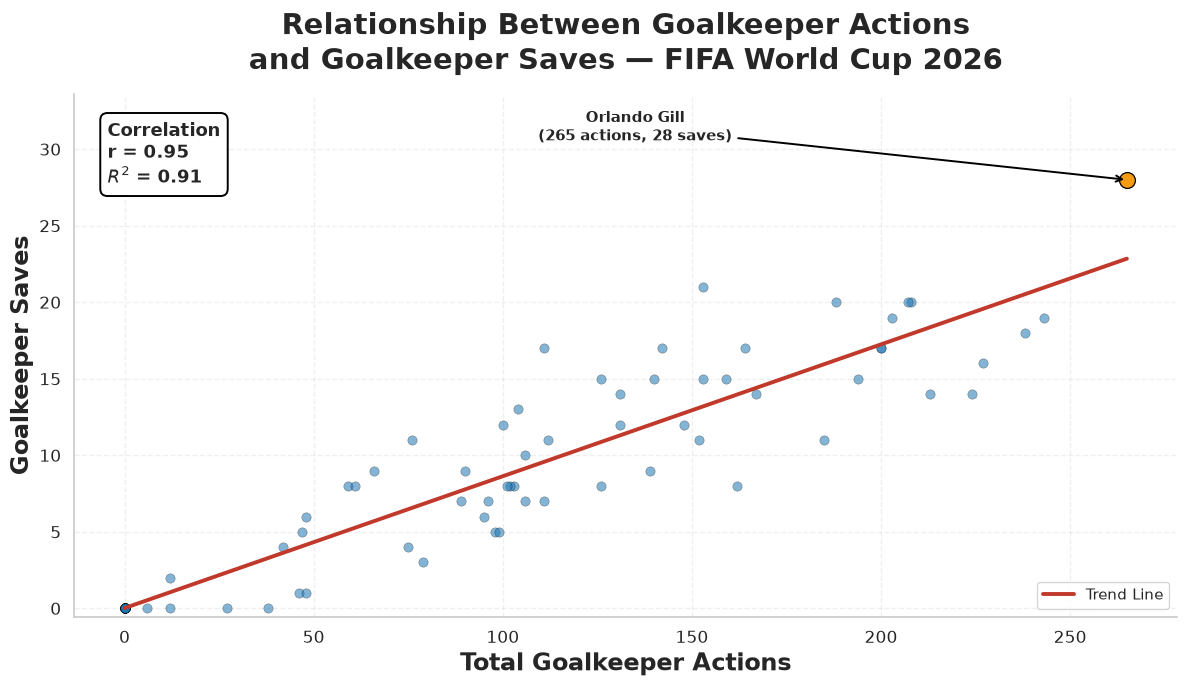

In [73]:
# ==========================================================
# Chart 13: Relationship Between Goalkeeper Actions
# and Goalkeeper Saves
# ==========================================================

fig, ax = plt.subplots(figsize=(12, 7))

x = goalkeeping["Total Actions"]
y = goalkeeping["Goalkeeper Saves"]

# Scatter points
ax.scatter(
    x,
    y,
    color="#1f77b4",
    edgecolors="black",
    linewidth=0.3,
    alpha=0.55,
    s=45,
    zorder=2
)

# Trend line — red, matching the other scatter charts in the deck
m, b = np.polyfit(x, y, 1)
x_range = np.linspace(x.min(), x.max(), 100)

ax.plot(
    x_range,
    m * x_range + b,
    color="#c0392b",
    linewidth=2.8,
    zorder=3,
    label="Trend Line"
)

# Correlation — bolder box, same weight as the other charts
r = x.corr(y)

ax.text(
    0.03,
    0.95,
    f"Correlation\nr = {r:.2f}\n$R^2$ = {r**2:.2f}",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="black",
        linewidth=1.4
    )
)

# --- Headroom before placing the callout ---
x_pad = (x.max() - x.min()) * 0.05
y_pad = (y.max() - y.min()) * 0.20

ax.set_xlim(x.min() - x_pad, x.max() + x_pad)
ax.set_ylim(y.min() - (y.max()*0.02), y.max() + y_pad)

# --- Highlighted leader point — gold, distinct from the red trend line ---
leader = goalkeeping.loc[y.idxmax()]

ax.scatter(
    leader["Total Actions"],
    leader["Goalkeeper Saves"],
    color="#f39c12",
    edgecolors="black",
    linewidth=0.9,
    s=130,
    zorder=5
)

# --- Callout states both raw values, positioned above-left where
#     it's guaranteed clear (Orlando Gill is both max-x and max-y here,
#     so nothing else occupies that region of the plot) ---
ax.annotate(
    f"{leader['Player']}\n"
    f"({int(leader['Total Actions'])} actions, "
    f"{int(leader['Goalkeeper Saves'])} saves)",
    xy=(
        leader["Total Actions"],
        leader["Goalkeeper Saves"]
    ),
    xytext=(
        leader["Total Actions"] - 130,
        leader["Goalkeeper Saves"] + y_pad*0.4
    ),
    fontsize=11,
    fontweight="bold",
    ha="center",
    va="bottom",
    arrowprops=dict(
        arrowstyle="->",
        lw=1.4,
        color="black"
    ),
    zorder=6
)

# Title
ax.set_title(
    "Relationship Between Goalkeeper Actions\nand Goalkeeper Saves — FIFA World Cup 2026",
    fontsize=21,
    fontweight="bold",
    pad=18
)

# Labels
ax.set_xlabel(
    "Total Goalkeeper Actions",
    fontsize=17,
    fontweight="bold"
)

ax.set_ylabel(
    "Goalkeeper Saves",
    fontsize=17,
    fontweight="bold"
)

ax.tick_params(axis="both", labelsize=12)

# Grid
ax.grid(
    linestyle="--",
    linewidth=1,
    alpha=0.3
)

ax.set_axisbelow(True)

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="lower right",
    fontsize=11,
    frameon=True,
    edgecolor="#cccccc"
)

plt.tight_layout()

plt.savefig(
    "../charts/13_saves_vs_total_goalkeeper_actions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Analysis:** The near-perfect correlation (r ≈ 0.95) between total actions and saves is expected — keepers facing more shots will mechanically accumulate both stats. The more interesting metric is **save rate** (saves / total actions), which ranges from ~8% to ~15% across the top keepers. Orlando Gill's outlier position reflects Paraguay's defensive strategy: his team allowed many shots, giving him both high total actions and high save counts. For goalkeeper evaluation, save rate and actions-inside-box ratio are more informative than raw save counts.


## 7. Key Insights Summary

This section synthesizes the most important findings across all analyses into actionable takeaways.

### Attacking & Scoring

| Insight | Evidence |
|---------|----------|
| Goals, assists, and xG are heavily right-skewed | Median xG = 0.02, median goals = 0; only 24% had xG > 1.0 |
| Mbappé dominates all attacking metrics | 6.54 xG (3x next player), 10 goals, 4 assists |
| Position confounds minutes-vs-goals correlation | Correlation rose from r=0.34 to r=0.48 when restricting to FW/MF |
| Minutes played is only a partial predictor | Even among attackers, 77.6% scored zero goals |

### Passing & Distribution

| Insight | Evidence |
|---------|----------|
| The "funnel effect" is real | Low-volume passers: std=14.6%; High-volume (100+): std=2.0% |
| Rodri is the standout passer | 799 passes at 96.8% accuracy — elite volume AND quality |
| Minimum-sample filters are essential | Without 50-pass filter, rankings are statistically meaningless |
| Raw accuracy column was misleading | Recalculating from counts changed the actual top-10 ranking |

### Discipline

| Insight | Evidence |
|---------|----------|
| Simple yellow-card ranking is insufficient | Misses all 15 players with red cards |
| Infraction Score surfaces real offenders | All top 10 have at least one red card |
| Discipline issues are rare overall | 81.1% of players finished with zero yellow cards |

### Defending & Goalkeeping

| Insight | Evidence |
|---------|----------|
| Pressing volume predicts ball-winning | Pressures vs Turnovers: r = 0.80, p < 0.001 |
| Save count is workload-dependent | Saves vs Actions: r = 0.95 (mechanical relationship) |
| Save rate is a better goalkeeper metric | Normalizes for shot volume faced by each keeper |

### Cross-Cutting Findings

| Finding | Implication |
|---------|-------------|
| Zero-inflation is universal | Goals, assists, xG, yellow cards, saves all show the same pattern |
| Data quality issues exist but are documented | 200% conversion rate, 223 NaN from recalculation, 11-player gap |
| Small samples produce noisy estimates | Accuracy rankings require minimum thresholds |
| Power-law patterns dominate elite sports | Top 5% of players account for disproportionate output |

---


## 8. Final Conclusion

This analysis of **1,242 players** across **6 statistical categories** from the FIFA World Cup 2026 reveals several fundamental patterns in elite football performance:

**The Pareto Principle applies to football.** A small group of elite players — led by Mbappé (10 goals, 6.54 xG), Olise (7 assists), and Rodri (799 passes at 96.8%) — account for a disproportionate share of statistical output across every metric. This power-law distribution is consistent with research on performance inequality in team sports.

**Context matters more than raw numbers.** Goalkeeper save counts are confounded by team defensive strength. Passing accuracy rankings are meaningless without volume filters. Yellow card counts miss the most serious offenders who received red cards. Every metric in this project benefits from contextual normalization.

**Data quality discipline is essential.** We identified and documented three data quality issues (impossible conversion rate, 223 NaN from recalculation, 11-player goalkeeper gap) rather than silently ignoring them. Transparency about data limitations is a hallmark of professional analysis.

**For scouts and analysts:** The most actionable findings are (1) pressing volume as a ball-winning proxy (r = 0.80), (2) the necessity of minimum-sample filters for ratio metrics, and (3) the funnel pattern in passing accuracy that warns against trusting low-sample estimates.

---

## 9. Future Improvements

If this project were to be extended, the following enhancements would add significant value:

1. **Tactical clustering** — Apply K-Means or hierarchical clustering to identify distinct player archetypes (e.g., "box-to-box midfielder," "deep-lying playmaker") using combined metrics from multiple datasets.
2. **Team-level aggregation** — Aggregate player stats by national team to compare tactical profiles (e.g., France's attack-heavy vs. Paraguay's defense-first approach).
3. **Advanced metrics** — Calculate derived metrics like expected assists (xA), shot-creating actions, and progressive passes per 90 minutes.
4. **Match-by-match tracking** — If match-level data becomes available, track performance progression across the tournament to identify players who peaked in knockout stages.
5. **Interactive dashboard** — Build a Streamlit or Plotly Dash application allowing users to filter by position, country, and tournament stage for custom analysis.
6. **Cross-tournament comparison** — Compare 2026 metrics with 2022 World Cup data to identify trends in how the game is evolving.

---

## References

- **Data Source:** [FIFA World Cup 2026 Player Statistics](https://www.fifa.com/fifaplus/en/tournaments/mens/worldcup/canadamexicousa2026/player-stats)
- **Expected Goals (xG):** A statistical measure of the quality of each shot, estimating the probability it will result in a goal based on historical data.
- **Pearson Correlation:** Measures the linear relationship between two variables, ranging from -1 (perfect negative) to +1 (perfect positive).
- **Power Law Distribution:** A probability distribution where a small number of items account for a large share of total output — commonly observed in sports performance data.

---

*Project by Muhammad Ahtsham Javed & Abdul Manan | Data Analysis Course | 2026*


## 10. Export Clean Data

In [74]:
# Final data-quality checkpoint before saving processed files
print("Final missing value summary across all datasets:")
print("-" * 60)
for name, df in datasets.items():
    n_missing = df.isnull().sum().sum()
    print(f"{name:<15} | {n_missing:>4} missing values | {df.shape[0]:>5} rows | {df.shape[1]:>3} columns")


Final missing value summary across all datasets:
------------------------------------------------------------
Attacking       |    0 missing values |  1242 rows |  14 columns
Defending       |    0 missing values |  1242 rows |   8 columns
Discipline      |    0 missing values |  1242 rows |  11 columns
Distribution    |  223 missing values |  1242 rows |  14 columns
Goalkeeping     |    0 missing values |   145 rows |   8 columns
Golden Boot     |    0 missing values |  1231 rows |   7 columns


In [75]:
# Save all cleaned DataFrames to data/processed/
processed_dir = "../data/processed/"

attacking.to_csv(processed_dir + "Attacking.csv", index=False)
defending.to_csv(processed_dir + "Defending.csv", index=False)
discipline.to_csv(processed_dir + "Discipline.csv", index=False)
distribution.to_csv(processed_dir + "Distribution.csv", index=False)
goalkeeping.to_csv(processed_dir + "Goalkeeping.csv", index=False)
golden_boot.to_csv(processed_dir + "Golden_Boot.csv", index=False)

print("All processed files saved successfully.")


All processed files saved successfully.
